# Theta vs Random vs LHS


1. **Načtou se data**

2. **Nastavení**

3. **Random metoda**

4. **LHS metoda**

5. **Theta metoda**

6. **Pro každou metodu se fituje SAPCE model**

7. **Zkouší se více konfigurací modelu**

8. **Spočítají se chyby na čistém nezávislém testu**

9. **Vykreslí se grafy**


In [5]:
import copy
import random
import traceback
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from UQpy.distributions import Normal, Uniform, JointIndependent
from UQpy.sampling.ThetaCriterionPCE import ThetaCriterionPCE

import SAPCE


In [6]:
# Načtení dat - ze souboru
def load_dataset(data_file):
    data = pd.read_csv(data_file, sep=";", header=0)

    for col in data.columns:
        if data[col].dtype == object:
            data[col] = pd.to_numeric(
                data[col].astype(str).str.replace(",", ".", regex=False),
                errors="raise"
            )

    arr = data.to_numpy()
    X = arr[:, :12]
    Y = arr[:, 12:]

    if X.shape[1] != 12:
        raise ValueError(f"Dataset {data_file} has {X.shape[1]} input columns, expected 12")

    if Y.shape[1] == 0:
        raise ValueError(f"Dataset {data_file} has no output columns after the first 12 columns")

    return X, Y


Nastavení

In [8]:
# Nastavení
DATA_FILES = [
     "Oakwood_NVM.csv",
    "Oakwood_N.csv",
    "Oakwood_V.csv",
    "Oakwood_M.csv",
]

SEED = 1
N_REPEATS = 20
TEST_SIZE = 300

# Velikosti trénovací množiny
nsim = np.arange(15, 100, 10)

# Grid - pro různé soubory může být výhodné jiné nastavení SAPCE.
degree_list = [2, 3, 5]
cond_list = [10, 100, 1000]
cr_list = [1e-8]
ratio_list = [0.30, 0.40, 0.50, 0.70]

METHODS = ["Random", "LHS", "Theta"]

# Theta zvolení kolik výstupů uvidí, None = všechny.
THETA_OUTPUT_INDICES = None

# Kontrola převodu PCE.
VERIFY_PCE_CONVERSION = True
PCE_VERIFY_ATOL = 1e-8
PCE_VERIFY_RTOL = 1e-6

n_inputs = 12
linear_terms = n_inputs + 1


In [9]:
# Rozdělení vstupů
marg = [
    Normal(13, 1),
    Uniform(30, 40),
    Uniform(2, 1),
    Normal(65, 5),
    Normal(30, 5),
    Normal(30, 1),
    Uniform(0.6, 0.5),
    Uniform(2, 1),
    Normal(130, 10),
    Normal(5, 1),
    Normal(42, 1),
    Uniform(0.45, 0.2)
]

joint = JointIndependent(marginals=marg)


In [10]:

# Univerzální predikce PCE objektu.
def predict_pce(pce, X_in):
    X_in = np.asarray(X_in, dtype=float)

    for name in ["predict", "evaluate", "run"]:
        if hasattr(pce, name):
            try:
                return np.asarray(getattr(pce, name)(X_in))
            except TypeError:
                pass

    if callable(pce):
        return np.asarray(pce(X_in))

    raise AttributeError("PCE object has no usable prediction method")


# Převod multi-output PCE na list jedno-výstupových PCE.
def pce_multioutput_to_singleoutput_list(pce, output_indices=None):
    coef = np.asarray(pce.coefficients)

    if coef.ndim == 1:
        coef = coef.reshape(-1, 1)

    n_outputs = coef.shape[1]

    if output_indices is None:
        output_indices = range(n_outputs)
    else:
        output_indices = [int(i) for i in output_indices]

    pce_list = []

    for j in output_indices:
        if j < 0 or j >= n_outputs:
            raise IndexError(f"output index {j} out of range")

        pce_j = copy.deepcopy(pce)
        pce_j.coefficients = coef[:, [j]]
        pce_list.append(pce_j)

    return pce_list


# Hlavní funkce pro ThetaCriterionPCE.
def select_theta_points_from_sapce(
    sapce,
    existing_samples,
    candidate_samples,
    nsamples=1,
    candidate_indices=None,
    output_indices=None,
    pce_weights=None,
    samples_weights=None,
    candidate_weights=None,
    verify_conversion=True,
    x_verify=None,
    atol=1e-8,
    rtol=1e-6,
):
    existing_samples = np.asarray(existing_samples, dtype=float)
    candidate_samples = np.asarray(candidate_samples, dtype=float)

    if candidate_samples.shape[0] == 0:
        raise ValueError("candidate_samples is empty")

    nsamples = int(nsamples)
    nsamples = max(1, min(nsamples, candidate_samples.shape[0]))

    pce_list = pce_multioutput_to_singleoutput_list(
        sapce.pce,
        output_indices=output_indices,
    )

    theta = ThetaCriterionPCE(pce_list)

    selected_pos = theta.run(
        existing_samples=existing_samples,
        candidate_samples=candidate_samples,
        nsamples=nsamples,
        samples_weights=samples_weights,
        candidate_weights=candidate_weights,
        pce_weights=pce_weights,
    )

    selected_pos = np.asarray(selected_pos, dtype=int).ravel()

    if selected_pos.size == 0:
        raise RuntimeError("ThetaCriterionPCE returned no selected positions")

    if np.any(selected_pos < 0) or np.any(selected_pos >= candidate_samples.shape[0]):
        raise IndexError(f"ThetaCriterionPCE returned positions outside candidate range: {selected_pos}")

    selected_global = None
    if candidate_indices is not None:
        candidate_indices = np.asarray(candidate_indices, dtype=int)
        selected_global = candidate_indices[selected_pos]

    return {
        "selected_pos": selected_pos,
        "selected_global_idx": selected_global,
        "conversion_info": None,
        "pce_list": pce_list,
    }


Funkce pro Sapce

In [12]:
def max_ratio_for_n(n_train):
    # Určí max. poměr
    min_ratio = (linear_terms + 0.5) / n_train

    if n_train < 30:
        base = 0.90
    elif n_train < 60:
        base = 0.70
    elif n_train < 100:
        base = 0.55
    elif n_train < 200:
        base = 0.60
    else:
        base = 0.70

    return min(0.95, max(base, min_ratio))


def ratio_candidates(n_train):
    # Vybere poměry
    upper = max_ratio_for_n(n_train)

    out = [
        r for r in ratio_list
        if r <= upper and int(np.floor(r * n_train)) >= linear_terms
    ]

    if len(out) == 0:
        out = [min(0.95, (linear_terms + 0.5) / n_train)]

    if not any(np.isclose(upper, r) for r in out):
        if int(np.floor(upper * n_train)) >= linear_terms:
            out.append(upper)

    return sorted(out)


def admissible_neighbors_fn():
    # Najde sousedy
    if hasattr(SAPCE, "admissible_neighbors"):
        return SAPCE.admissible_neighbors

    glb = SAPCE.SensitivityAdaptivePCE.construct_adaptive_basis.__globals__

    if "admissible_neighbors" in glb:
        return glb["admissible_neighbors"]

    raise RuntimeError("admissible_neighbors not found")


def filter_indices(indices, degree):
    # Filtruje indexy
    out = []

    for idx in indices:
        idx = np.asarray(idx, dtype=int)

        if np.sum(idx) <= degree and np.all(idx <= degree):
            out.append(idx.tolist())

    return out


def adaptive_basis_rollback(sapce, cond_limit, ratio_limit):
    # Staví bázi
    neigh = admissible_neighbors_fn()
    n_train = sapce.exp_design_in.shape[0]
    max_terms = int(np.floor(ratio_limit * n_train))

    while True:
        terms = len(sapce.pce.multi_index_set)

        if terms >= n_train:
            return "basis_ge_n_train"

        if terms >= max_terms:
            return "basis_ge_ratio"

        if sapce.condition_number > cond_limit:
            return "condition_too_large"

        new_idx = neigh(
            sapce.active_multi_indices[-1],
            sapce.active_multi_indices
        )

        new_idx = filter_indices(new_idx, sapce.max_partial_degree)

        if len(new_idx) == 0:
            return "no_new_indices"

        proposed_terms = (
            len(sapce.active_multi_indices)
            + len(sapce.admissible_multi_indices)
            + len(new_idx)
        )

        if proposed_terms >= n_train:
            return "proposed_ge_n_train"

        if proposed_terms > max_terms:
            return "proposed_ge_ratio"

        old_active = copy.deepcopy(sapce.active_multi_indices)
        old_admissible = copy.deepcopy(sapce.admissible_multi_indices)
        old_multi = copy.deepcopy(sapce.pce.multi_index_set)

        sapce.admissible_multi_indices += new_idx
        sapce.set_multi_index_set(
            sapce.active_multi_indices + sapce.admissible_multi_indices
        )
        sapce.compute_coefficients()

        if sapce.condition_number > cond_limit:
            sapce.active_multi_indices = old_active
            sapce.admissible_multi_indices = old_admissible
            sapce.set_multi_index_set(old_multi)
            sapce.compute_coefficients()

            return "rollback"

        i0 = len(sapce.active_multi_indices)
        coef = np.asarray(sapce.pce.coefficients[i0:])

        if coef.size == 0:
            return "no_coefficients"

        if coef.ndim == 1:
            score = np.abs(coef)
        else:
            score = np.sum(np.abs(coef), axis=1)

        best = int(np.argmax(score))
        sapce.active_multi_indices.append(
            sapce.admissible_multi_indices.pop(best)
        )


def make_split(n_total, test_size, max_train_size, seed):
    # Rozdělí indexy na nezávislý test a trénovací pool.
    # Testovací body se nesmí použít pro výběr konfigurace ani pro Theta.
    rng = random.Random(seed)
    idx = list(range(n_total))
    rng.shuffle(idx)

    test_idx = idx[:test_size]
    train_pool = idx[test_size:]

    if len(train_pool) < max_train_size:
        raise ValueError("Training pool is smaller than the requested maximum training size.")

    # Ponecháno kvůli kompatibilitě se zbytkem kódu.
    remaining_pool = []

    return test_idx, train_pool, remaining_pool


def split_data(X, Y, train_idx, test_idx):
    # Rozdělí data
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


Konfigurace

In [14]:
# Nejlepší konfigurace

def maximum_absolute_error_per_output(pce, Xte, Yte):
    # Predikce
    y_pred = np.asarray(predict_pce(pce, Xte), dtype=float)

    # Skutečnost
    y_true = np.asarray(Yte, dtype=float)

    if y_pred.ndim == 1:
        y_pred = y_pred[:, None]

    if y_true.ndim == 1:
        y_true = y_true[:, None]

    if y_pred.shape != y_true.shape:
        raise ValueError(f"Prediction shape {y_pred.shape} does not match Yte shape {y_true.shape}")

    # Max chyba
    return np.max(np.abs(y_pred - y_true), axis=0)


def fit_one_config(Xtr, Ytr, Xte, Yte, degree, cond_limit, ratio_limit, cr, return_model=False):
    # SAPCE model
    sapce = SAPCE.SensitivityAdaptivePCE(
        pdf=joint,
        exp_design_in=Xtr,
        exp_design_out=Ytr,
        max_partial_degree=degree,
        num_inputs=12
    )

    # Adaptivní báze
    status = adaptive_basis_rollback(sapce, cond_limit, ratio_limit)

    # Počet členů
    terms_before = len(sapce.pce.multi_index_set)

    # Prořezání PCE
    sapce.construct_pruned_pce(cr=cr)

    # Počet členů
    terms_after = len(sapce.pce.multi_index_set)

    # Validační chyba
    err = np.asarray(sapce.pce.validation_error(Xte, Yte)).ravel()

    # Max chyba
    max_abs_err = maximum_absolute_error_per_output(sapce.pce, Xte, Yte)

    # Podmíněnost
    cond = float(sapce.condition_number)

    # Počet členů
    terms = len(sapce.pce.multi_index_set)

    # Poměr báze
    ratio = terms / Xtr.shape[0]

    # Platnost modelu
    valid = (
        np.all(np.isfinite(err))
        and np.all(err >= 0)
        and np.all(np.isfinite(max_abs_err))
        and np.all(max_abs_err >= 0)
        and cond <= cond_limit
        and terms < Xtr.shape[0]
        and ratio <= ratio_limit
    )

    # Výsledky
    out = {
        "degree": degree,
        "cond_limit": cond_limit,
        "ratio_limit": ratio_limit,
        "cr": cr,
        "err": err,
        "max_abs_err": max_abs_err,
        "mean": float(np.mean(err)),
        "median": float(np.median(err)),
        "max": float(np.max(err)),
        "max_abs_mean": float(np.mean(max_abs_err)),
        "max_abs_median": float(np.median(max_abs_err)),
        "max_abs_max": float(np.max(max_abs_err)),
        "cond": cond,
        "terms": terms,
        "ratio": ratio,
        "removed": terms_before - terms_after,
        "status": status,
        "valid": valid
    }

    # Vrácení modelu
    if return_model:
        out["sapce"] = sapce

    return out


def find_best_config(Xtr, Ytr, Xte, Yte, n_train):
    # Všechny výsledky
    results = []

    # Test konfigurací
    for degree in degree_list:
        for cond_limit in cond_list:
            for ratio_limit in ratio_candidates(n_train):
                for cr in cr_list:
                    try:
                        results.append(
                            fit_one_config(
                                Xtr, Ytr, Xte, Yte,
                                degree, cond_limit, ratio_limit, cr,
                                return_model=False,
                            )
                        )
                    except Exception:
                        pass

    # Platné modely
    valid = [r for r in results if r["valid"]]

    # Bez modelu
    if len(valid) == 0:
        return None, results

    # Skóre modelu
    def score(r):
        return (
            r["mean"]
            + 1e-5 * r["ratio"]
            + 1e-8 * np.log10(r["cond"] + 1.0)
        )

    # Nejlepší model
    return min(valid, key=score), results


In [15]:
# LHS výběr a Theta výběr bodů.
def unit_bounds(X_ref):
    # Rozsah škálování
    X_ref = np.asarray(X_ref, dtype=float)
    x_min = np.min(X_ref, axis=0)
    x_max = np.max(X_ref, axis=0)
    x_range = x_max - x_min
    x_range = np.where(x_range > 0.0, x_range, 1.0)
    return x_min, x_range


def to_unit_cube(X_in, x_min, x_range):
    # Převod na unit cube
    X_in = np.asarray(X_in, dtype=float)
    X_unit = (X_in - x_min) / x_range
    return np.clip(X_unit, 0.0, 1.0)


def latin_hypercube_unit(n_samples, n_dim, seed):
    # Vytvoří LHS cíle
    n_samples = int(n_samples)
    n_dim = int(n_dim)

    if n_samples <= 0:
        return np.empty((0, n_dim))

    rng = np.random.default_rng(seed)
    samples = np.empty((n_samples, n_dim), dtype=float)

    for j in range(n_dim):
        perm = rng.permutation(n_samples)
        samples[:, j] = (perm + rng.random(n_samples)) / n_samples

    return samples


def nearest_unique_positions(candidate_unit, target_unit):
    # Nejbližší reálné body
    candidate_unit = np.asarray(candidate_unit, dtype=float)
    target_unit = np.asarray(target_unit, dtype=float)

    remaining = np.ones(candidate_unit.shape[0], dtype=bool)
    selected_pos = []

    for target in target_unit:
        active = np.where(remaining)[0]

        if active.size == 0:
            break

        dist = np.sum((candidate_unit[active] - target) ** 2, axis=1)
        pos = int(active[int(np.argmin(dist))])
        selected_pos.append(pos)
        remaining[pos] = False

    return selected_pos


def build_lhs_training_order(
    X,
    initial_train_idx,
    candidate_pool,
    target_sizes,
    seed,
):
    # Sestaví LHS pořadí
    train_order = [int(i) for i in initial_train_idx]
    candidate_pool = [int(i) for i in candidate_pool]
    target_sizes = [int(n) for n in target_sizes]

    max_target = int(max(target_sizes))
    n_to_select = max(0, max_target - len(train_order))
    n_to_select = min(n_to_select, len(candidate_pool))

    lhs_logs = []

    if n_to_select > 0:
        # Škáluje se jen podle trénovacího poolu.
        scale_idx = train_order + candidate_pool
        x_min, x_range = unit_bounds(X[scale_idx])

        candidate_unit = to_unit_cube(X[candidate_pool], x_min, x_range)
        target_unit = latin_hypercube_unit(
            n_samples=n_to_select,
            n_dim=X.shape[1],
            seed=seed,
        )

        selected_pos = nearest_unique_positions(candidate_unit, target_unit)
        selected_global = [candidate_pool[p] for p in selected_pos]
        train_order.extend(selected_global)

    for target_size in target_sizes:
        n_before = min(len(initial_train_idx), target_size)
        n_added = max(0, min(target_size, len(train_order)) - len(initial_train_idx))

        if len(train_order) >= target_size:
            status = "lhs_ok"
        else:
            status = "not_enough_candidates"

        lhs_logs.append({
            "target_size": target_size,
            "n_before": n_before,
            "n_added": n_added,
            "status": status,
            "fallback": False,
        })

    return train_order, lhs_logs


# Doplnění funkce pro sestavení Theta pořadí trénovacích bodů.
def _find_best_config_for_theta(Xtr, Ytr, Xeval, Yeval, n_train):
    # Všechny výsledky
    results = []

    # Test konfigurací
    for degree in degree_list:
        for cond_limit in cond_list:
            for ratio_limit in ratio_candidates(n_train):
                for cr in cr_list:
                    try:
                        results.append(
                            fit_one_config(
                                Xtr, Ytr, Xeval, Yeval,
                                degree, cond_limit, ratio_limit, cr,
                                return_model=True,
                            )
                        )
                    except Exception:
                        pass

    # Platné modely
    valid = [r for r in results if r["valid"]]

    # Bez modelu
    if len(valid) == 0:
        return None, results

    # Skóre modelu
    def score(r):
        return (
            r["mean"]
            + 1e-5 * r["ratio"]
            + 1e-8 * np.log10(r["cond"] + 1.0)
        )

    # Nejlepší model včetně SAPCE objektu
    return min(valid, key=score), results


def build_theta_training_order(
    X,
    Y,
    initial_train_idx,
    candidate_pool,
    target_sizes,
):
    # Aktuální trénovací množina
    train_order = [int(i) for i in initial_train_idx]

    # Kandidáti pro Theta
    remaining_candidates = [int(i) for i in candidate_pool]

    theta_logs = []

    # Cílové velikosti trénovací množiny
    target_sizes = [int(n) for n in target_sizes]

    for target_size in target_sizes:
        # Pokud už máme dost bodů, pokračuj
        if len(train_order) >= target_size:
            theta_logs.append({
                "target_size": target_size,
                "n_before": len(train_order),
                "n_added": 0,
                "status": "already_enough",
                "degree": np.nan,
                "cond_limit": np.nan,
                "ratio_limit": np.nan,
                "cr": np.nan,
                "mean": np.nan,
                "max": np.nan,
                "fallback": False,
            })
            continue

        # Kolik bodů je potřeba doplnit
        n_to_add = target_size - len(train_order)

        # Pokud nejsou kandidáti, skonči
        if len(remaining_candidates) == 0:
            theta_logs.append({
                "target_size": target_size,
                "n_before": len(train_order),
                "n_added": 0,
                "status": "no_candidates",
                "degree": np.nan,
                "cond_limit": np.nan,
                "ratio_limit": np.nan,
                "cr": np.nan,
                "mean": np.nan,
                "max": np.nan,
                "fallback": True,
            })
            break

        n_to_add = min(n_to_add, len(remaining_candidates))

        Xtr = X[train_order]
        Ytr = Y[train_order]

        # Najdi nejlepší SAPCE model pouze podle aktuálních trénovacích bodů.
        # Nezávislá testovací množina se zde nepoužívá.
        best, all_results = _find_best_config_for_theta(
            Xtr,
            Ytr,
            Xtr,
            Ytr,
            len(train_order),
        )

        # Když model nejde sestavit, fallback = vezmi první dostupné kandidáty.
        if best is None:
            selected_global = remaining_candidates[:n_to_add]

            theta_logs.append({
                "target_size": target_size,
                "n_before": len(train_order),
                "n_added": len(selected_global),
                "status": "fallback_no_valid_model",
                "degree": np.nan,
                "cond_limit": np.nan,
                "ratio_limit": np.nan,
                "cr": np.nan,
                "mean": np.nan,
                "max": np.nan,
                "fallback": True,
            })

        else:
            try:
                theta_out = select_theta_points_from_sapce(
                    sapce=best["sapce"],
                    existing_samples=X[train_order],
                    candidate_samples=X[remaining_candidates],
                    nsamples=n_to_add,
                    candidate_indices=remaining_candidates,
                    output_indices=THETA_OUTPUT_INDICES,
                    verify_conversion=VERIFY_PCE_CONVERSION,
                    x_verify=Xtr,
                    atol=PCE_VERIFY_ATOL,
                    rtol=PCE_VERIFY_RTOL,
                )

                selected_global = [
                    int(i) for i in np.asarray(theta_out["selected_global_idx"]).ravel()
                ]

                theta_logs.append({
                    "target_size": target_size,
                    "n_before": len(train_order),
                    "n_added": len(selected_global),
                    "status": "theta_ok",
                    "degree": best["degree"],
                    "cond_limit": best["cond_limit"],
                    "ratio_limit": best["ratio_limit"],
                    "cr": best["cr"],
                    "mean": best["mean"],
                    "max": best["max"],
                    "fallback": False,
                })

            except Exception:
                # Když Theta selže, fallback = vezmi první dostupné kandidáty.
                selected_global = remaining_candidates[:n_to_add]

                theta_logs.append({
                    "target_size": target_size,
                    "n_before": len(train_order),
                    "n_added": len(selected_global),
                    "status": "fallback_theta_failed",
                    "degree": best["degree"],
                    "cond_limit": best["cond_limit"],
                    "ratio_limit": best["ratio_limit"],
                    "cr": best["cr"],
                    "mean": best["mean"],
                    "max": best["max"],
                    "fallback": True,
                })

        # Přidej vybrané body do trénovací množiny.
        train_order.extend(selected_global)

        # Odeber vybrané body z kandidátů.
        selected_set = set(selected_global)
        remaining_candidates = [
            i for i in remaining_candidates
            if i not in selected_set
        ]

    return train_order, theta_logs


In [16]:
# Jeden běh
def run_dataset(data_file, repeat_id=0, seed=SEED):
    dataset_name = os.path.splitext(os.path.basename(data_file))[0]

    X, Y = load_dataset(data_file)

    max_train_size = int(np.max(nsim))

    # Split dat: 300 bodů je nezávislá testovací množina, zbytek je trénovací pool.
    test_idx, prefix_train_pool, remaining_pool = make_split(
        n_total=X.shape[0],
        test_size=TEST_SIZE,
        max_train_size=max_train_size,
        seed=seed,
    )

    initial_n = int(np.min(nsim))
    initial_train_idx = prefix_train_pool[:initial_n]

    # Kandidáti - pouze z trénovacího poolu, nikdy z testovací množiny.
    candidate_pool = [
        i for i in prefix_train_pool
        if i not in set(initial_train_idx)
    ]

    lhs_full_order, lhs_logs = build_lhs_training_order(
        X=X,
        initial_train_idx=initial_train_idx,
        candidate_pool=candidate_pool,
        target_sizes=nsim,
        seed=seed + 10000,
    )

    theta_full_order, theta_logs = build_theta_training_order(
        X=X,
        Y=Y,
        initial_train_idx=initial_train_idx,
        candidate_pool=candidate_pool,
        target_sizes=nsim,
    )

    train_indices_by_method = {
        "Random": prefix_train_pool,
        "LHS": lhs_full_order,
        "Theta": theta_full_order,
    }

    # Chyby
    errs_by_method = {
        method: np.full((len(nsim), Y.shape[1]), np.nan)
        for method in METHODS
    }

    # Max chyba
    max_abs_by_method = {
        method: np.full((len(nsim), Y.shape[1]), np.nan)
        for method in METHODS
    }

    rows = []

    # Metody
    for method in METHODS:
        print(f"{dataset_name}_{method}_Seed {repeat_id + 1}/{N_REPEATS}")

        method_pool = train_indices_by_method[method]

        # Velikosti
        for i, n_train in enumerate(nsim):
            n_train = int(n_train)
            train_idx = method_pool[:n_train]

            Xtr = X[np.asarray(train_idx, dtype=int)]
            Ytr = Y[np.asarray(train_idx, dtype=int)]

            Xtest = X[np.asarray(test_idx, dtype=int)]
            Ytest = Y[np.asarray(test_idx, dtype=int)]

            # Najdi model pouze podle trénovacích dat.
            # Testovací množina se zde nepoužívá.
            best, all_results = find_best_config(
                Xtr,
                Ytr,
                Xtr,
                Ytr,
                n_train,
            )

            if best is None:
                rows.append({
                    "dataset": dataset_name,
                    "repeat": repeat_id,
                    "seed": seed,
                    "method": method,
                    "n_train": n_train,
                    "mean": np.nan,
                    "median": np.nan,
                    "max": np.nan,
                    "max_abs_mean": np.nan,
                    "max_abs_median": np.nan,
                    "max_abs_max": np.nan,
                    "condition": np.nan,
                    "basis_terms": np.nan,
                    "basis_ratio": np.nan,
                    "degree": np.nan,
                    "cond_limit": np.nan,
                    "ratio_limit": np.nan,
                    "cr": np.nan,
                    "valid_models": 0,
                    "tested_models": len(all_results),
                })
                continue

            # Finální vyhodnocení na nezávislé testovací množině.
            # Použije se konfigurace vybraná pouze z trénovacích dat.
            best_test = fit_one_config(
                Xtr,
                Ytr,
                Xtest,
                Ytest,
                best["degree"],
                best["cond_limit"],
                best["ratio_limit"],
                best["cr"],
                return_model=False,
            )

            errs_by_method[method][i, :] = best_test["err"]
            max_abs_by_method[method][i, :] = best_test["max_abs_err"]

            rows.append({
                "dataset": dataset_name,
                "repeat": repeat_id,
                "seed": seed,
                "method": method,
                "n_train": n_train,
                "mean": best_test["mean"],
                "median": best_test["median"],
                "max": best_test["max"],
                "max_abs_mean": best_test["max_abs_mean"],
                "max_abs_median": best_test["max_abs_median"],
                "max_abs_max": best_test["max_abs_max"],
                "condition": best_test["cond"],
                "basis_terms": best_test["terms"],
                "basis_ratio": best_test["ratio"],
                "degree": best["degree"],
                "cond_limit": best["cond_limit"],
                "ratio_limit": best["ratio_limit"],
                "cr": best["cr"],
                "valid_models": sum(r["valid"] for r in all_results),
                "tested_models": len(all_results),
            })

    res = pd.DataFrame(rows)

    # Kontrola: žádná metoda nesmí použít testovací body.
    for method in METHODS:
        overlap = len(set(test_idx).intersection(set(train_indices_by_method[method])))

        if overlap != 0:
            raise AssertionError(f"Training and test sets overlap for method {method}")

    return {
        "dataset": dataset_name,
        "repeat": repeat_id,
        "seed": seed,
        "X_shape": X.shape,
        "Y_shape": Y.shape,
        "results": res,
        "errs_by_method": errs_by_method,
        "max_abs_by_method": max_abs_by_method,
        "lhs_logs": lhs_logs,
        "theta_logs": theta_logs,
        "test_idx": test_idx,
        "prefix_train_pool": prefix_train_pool,
        "lhs_full_order": lhs_full_order,
        "theta_full_order": theta_full_order,
    }


# Všechny běhy
all_outputs = {
    os.path.splitext(os.path.basename(data_file))[0]: []
    for data_file in DATA_FILES
}

all_results = []

# Opakování
for repeat_id in range(N_REPEATS):
    repeat_seed = SEED + repeat_id

    # Datasety
    for data_file in DATA_FILES:
        out = run_dataset(
            data_file=data_file,
            repeat_id=repeat_id,
            seed=repeat_seed,
        )

        all_outputs[out["dataset"]].append(out)
        all_results.append(out["results"])

summary_df = pd.concat(all_results, ignore_index=True)

# Statistiky
stat_rows = []

for dataset_name, repeats in all_outputs.items():
    for method in METHODS:
        mean_curves = np.asarray([
            np.nanmean(rep["errs_by_method"][method], axis=1)
            for rep in repeats
        ])

        max_abs_curves = np.asarray([
            np.nanmax(rep["max_abs_by_method"][method], axis=1)
            for rep in repeats
        ])

        for i, n_train in enumerate(nsim):
            stat_rows.append({
                "dataset": dataset_name,
                "method": method,
                "n_train": int(n_train),
                "test_mean_avg": float(np.nanmean(mean_curves[:, i])),
                "test_mean_std": float(np.nanstd(mean_curves[:, i], ddof=1)),
                "test_mean_p05": float(np.nanpercentile(mean_curves[:, i], 5)),
                "test_mean_p95": float(np.nanpercentile(mean_curves[:, i], 95)),
                "max_abs_error_avg": float(np.nanmean(max_abs_curves[:, i])),
                "max_abs_error_std": float(np.nanstd(max_abs_curves[:, i], ddof=1)),
                "max_abs_error_p05": float(np.nanpercentile(max_abs_curves[:, i], 5)),
                "max_abs_error_p95": float(np.nanpercentile(max_abs_curves[:, i], 95)),
                "n_repeats": len(repeats),
            })

stats_df = pd.DataFrame(stat_rows)


Oakwood_NVM_Random_Seed 1/20
Oakwood_NVM_LHS_Seed 1/20
Oakwood_NVM_Theta_Seed 1/20
Oakwood_N_Random_Seed 1/20
Oakwood_N_LHS_Seed 1/20
Oakwood_N_Theta_Seed 1/20
Oakwood_V_Random_Seed 1/20
Oakwood_V_LHS_Seed 1/20
Oakwood_V_Theta_Seed 1/20
Oakwood_M_Random_Seed 1/20
Oakwood_M_LHS_Seed 1/20
Oakwood_M_Theta_Seed 1/20
Oakwood_NVM_Random_Seed 2/20
Oakwood_NVM_LHS_Seed 2/20
Oakwood_NVM_Theta_Seed 2/20
Oakwood_N_Random_Seed 2/20
Oakwood_N_LHS_Seed 2/20
Oakwood_N_Theta_Seed 2/20
Oakwood_V_Random_Seed 2/20
Oakwood_V_LHS_Seed 2/20
Oakwood_V_Theta_Seed 2/20
Oakwood_M_Random_Seed 2/20
Oakwood_M_LHS_Seed 2/20
Oakwood_M_Theta_Seed 2/20
Oakwood_NVM_Random_Seed 3/20
Oakwood_NVM_LHS_Seed 3/20
Oakwood_NVM_Theta_Seed 3/20
Oakwood_N_Random_Seed 3/20
Oakwood_N_LHS_Seed 3/20
Oakwood_N_Theta_Seed 3/20
Oakwood_V_Random_Seed 3/20
Oakwood_V_LHS_Seed 3/20
Oakwood_V_Theta_Seed 3/20
Oakwood_M_Random_Seed 3/20
Oakwood_M_LHS_Seed 3/20
Oakwood_M_Theta_Seed 3/20
Oakwood_NVM_Random_Seed 4/20
Oakwood_NVM_LHS_Seed 4/20
Oak

# Grafy

Saved: plots_output\Oakwood_NVM_01_Random_all_output_validation_errors.png


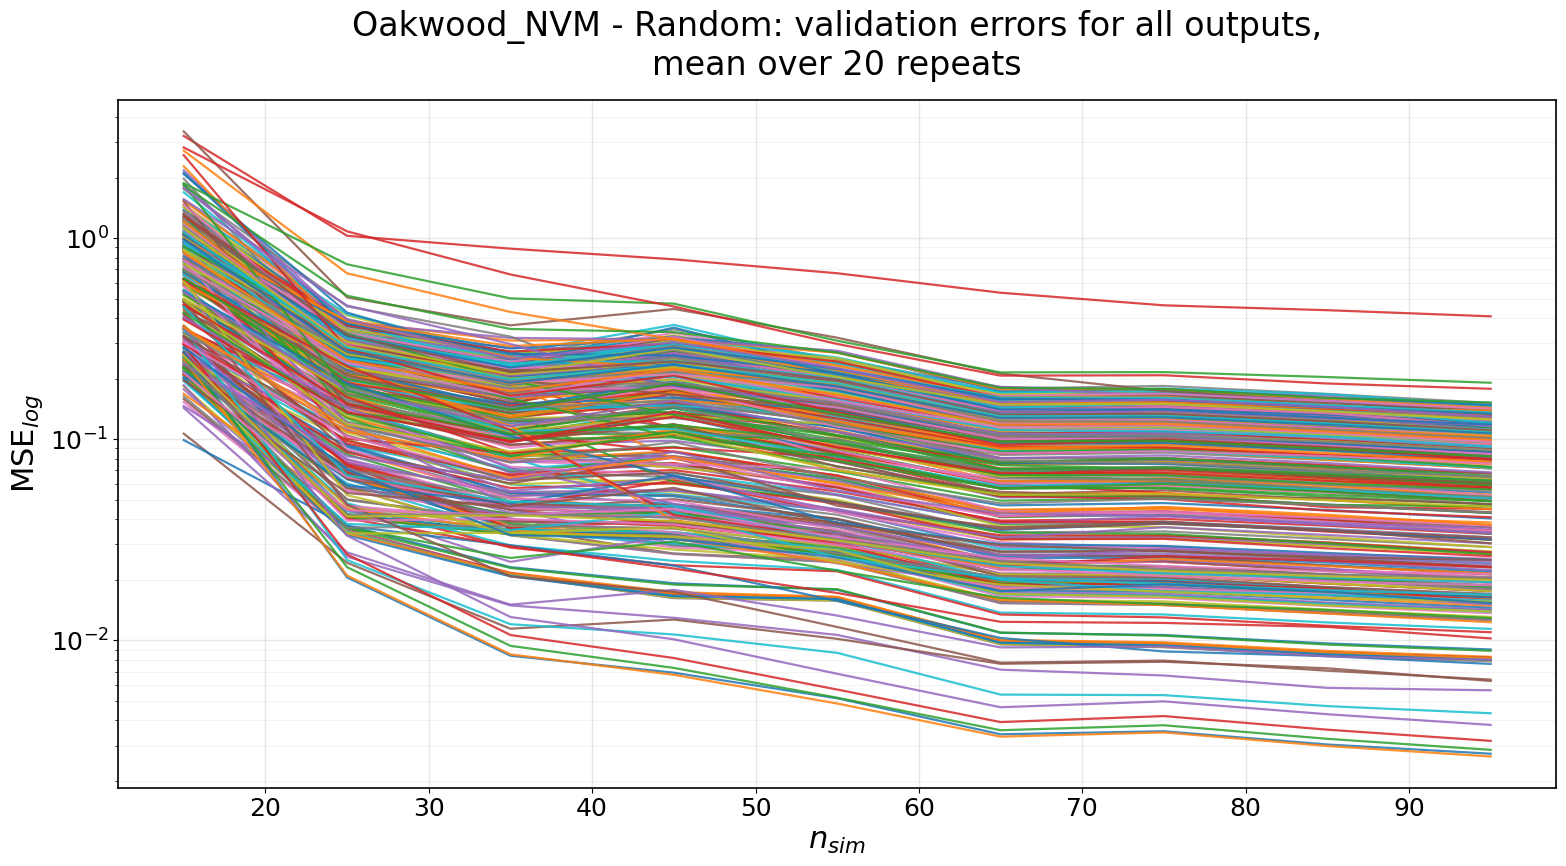

Saved: plots_output\Oakwood_NVM_02_Theta_all_output_validation_errors.png


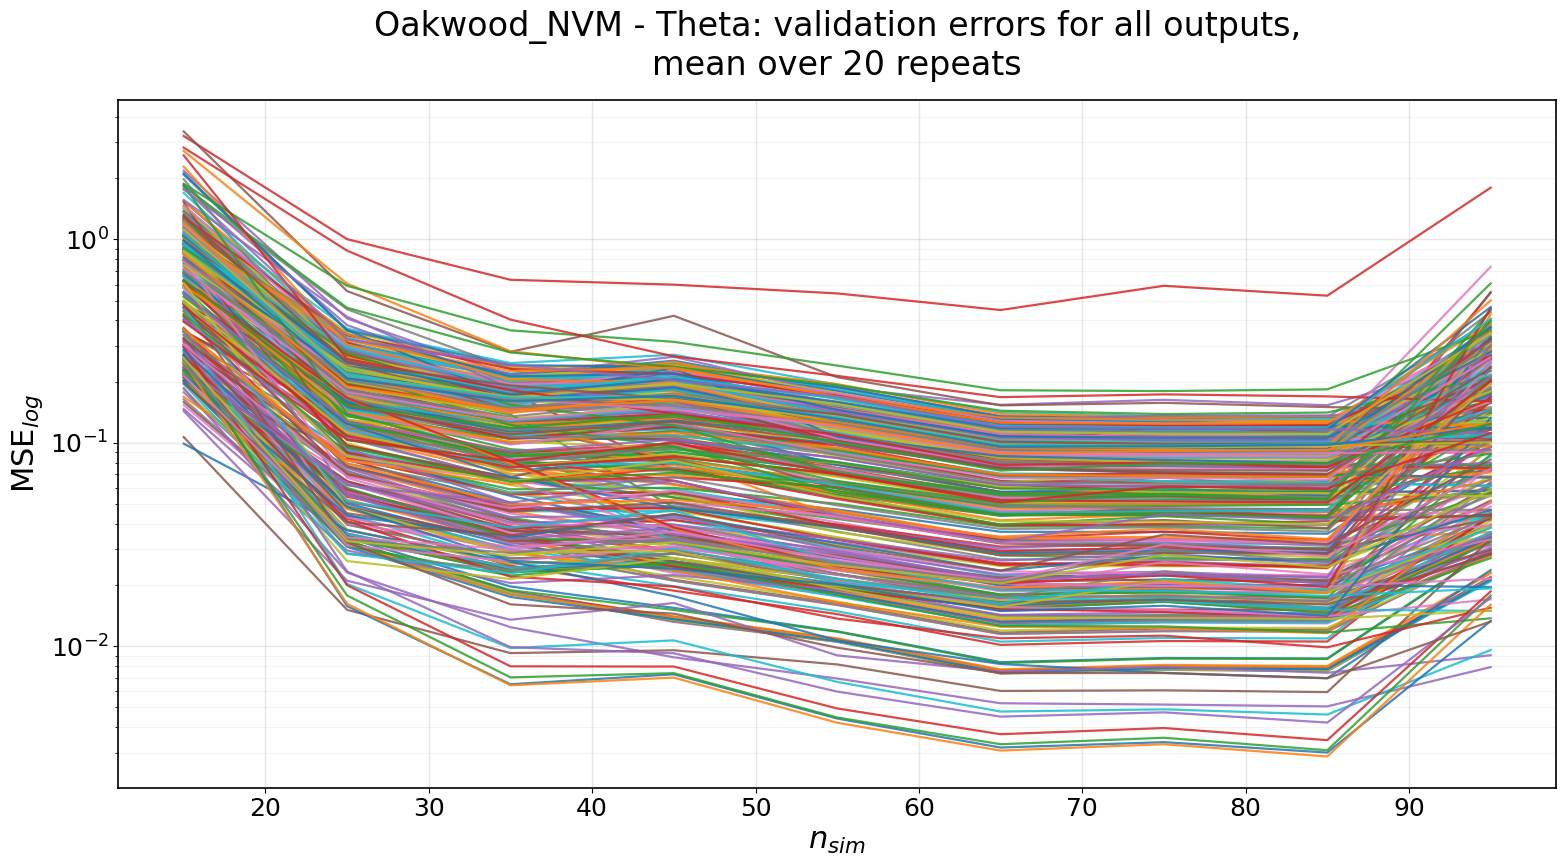

Saved: plots_output\Oakwood_NVM_03_Random_vs_Theta_mean_validation_error_std.png


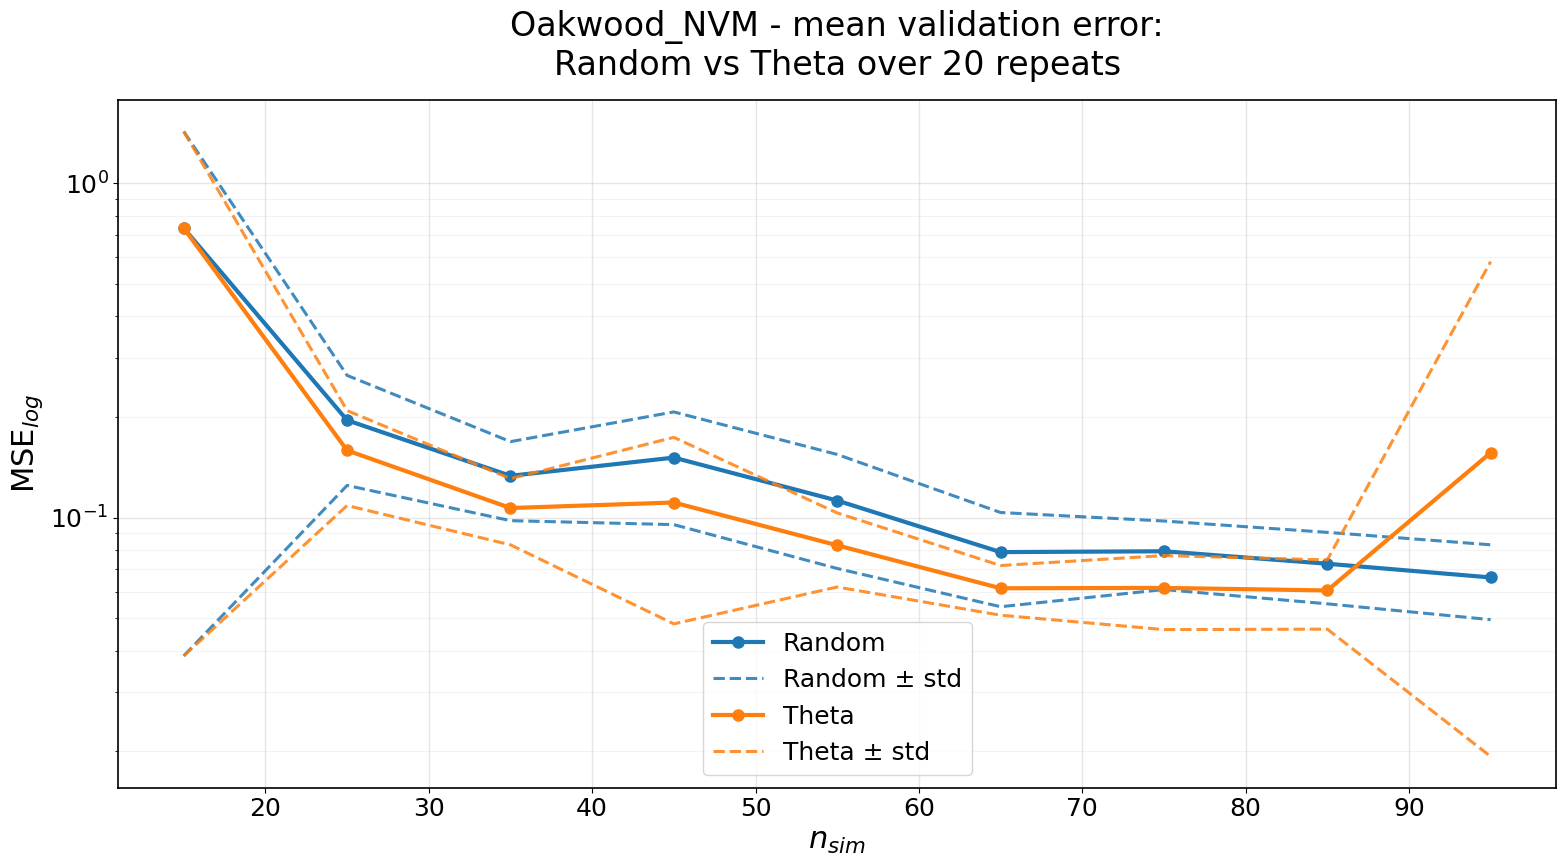

Saved: plots_output\Oakwood_NVM_04_Random_vs_Theta_maximum_absolute_error_std.png


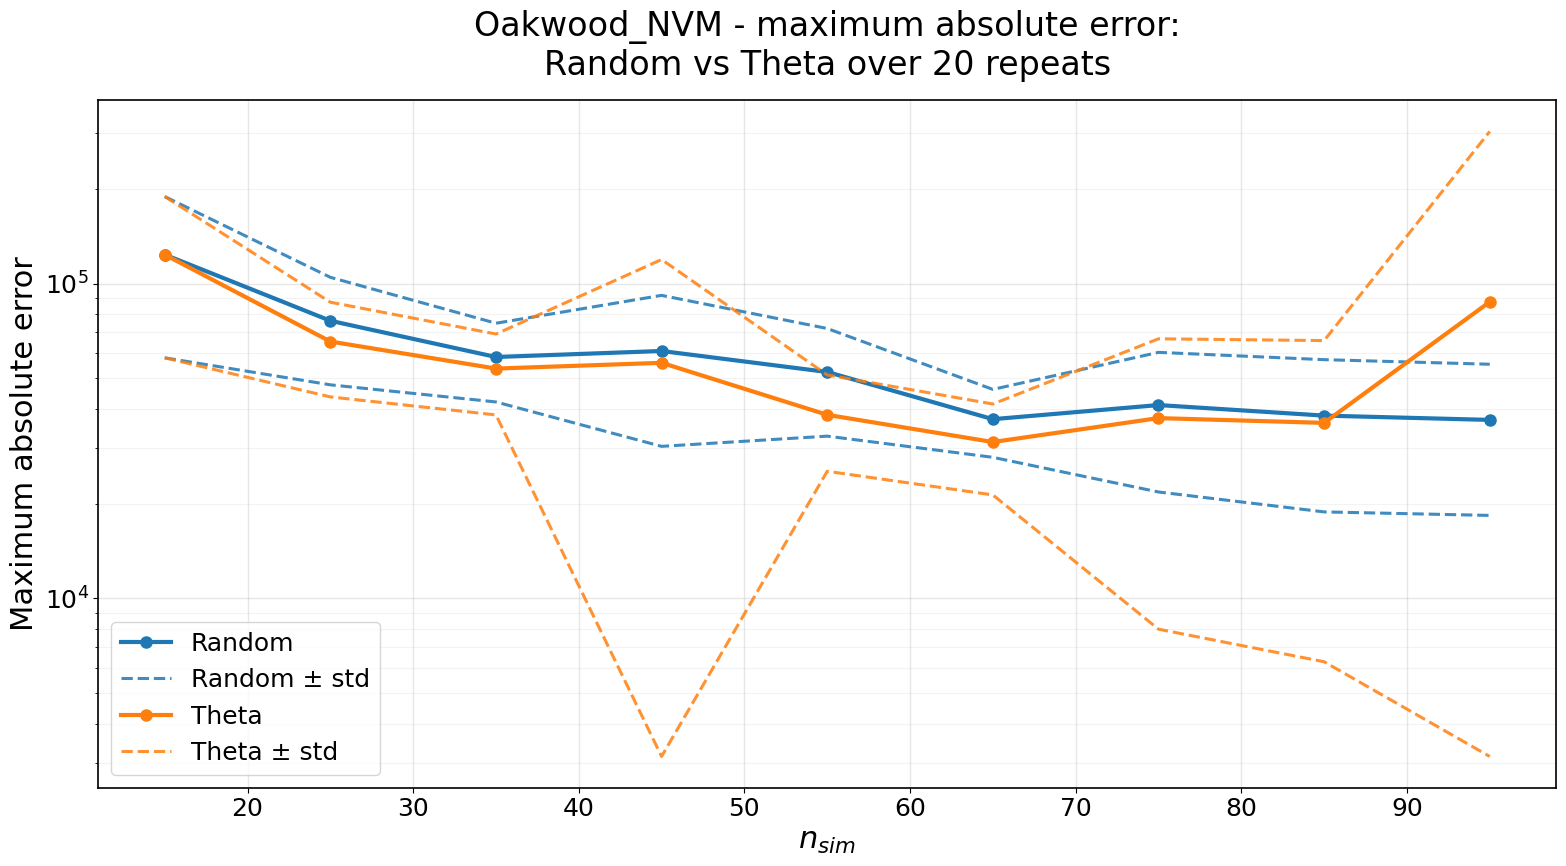

Saved: plots_output\Oakwood_N_01_Random_all_output_validation_errors.png


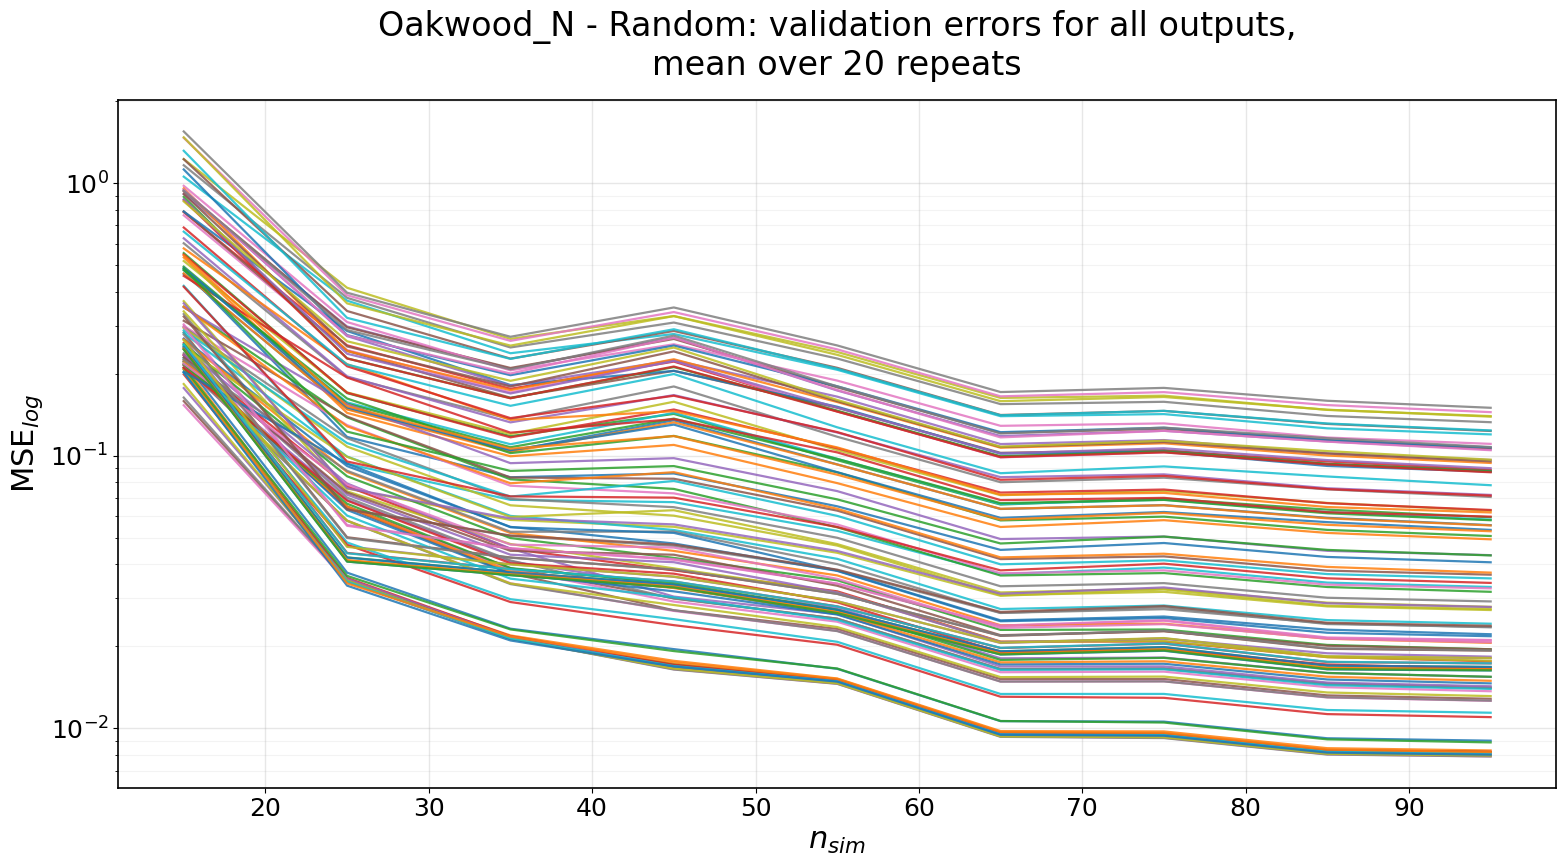

Saved: plots_output\Oakwood_N_02_Theta_all_output_validation_errors.png


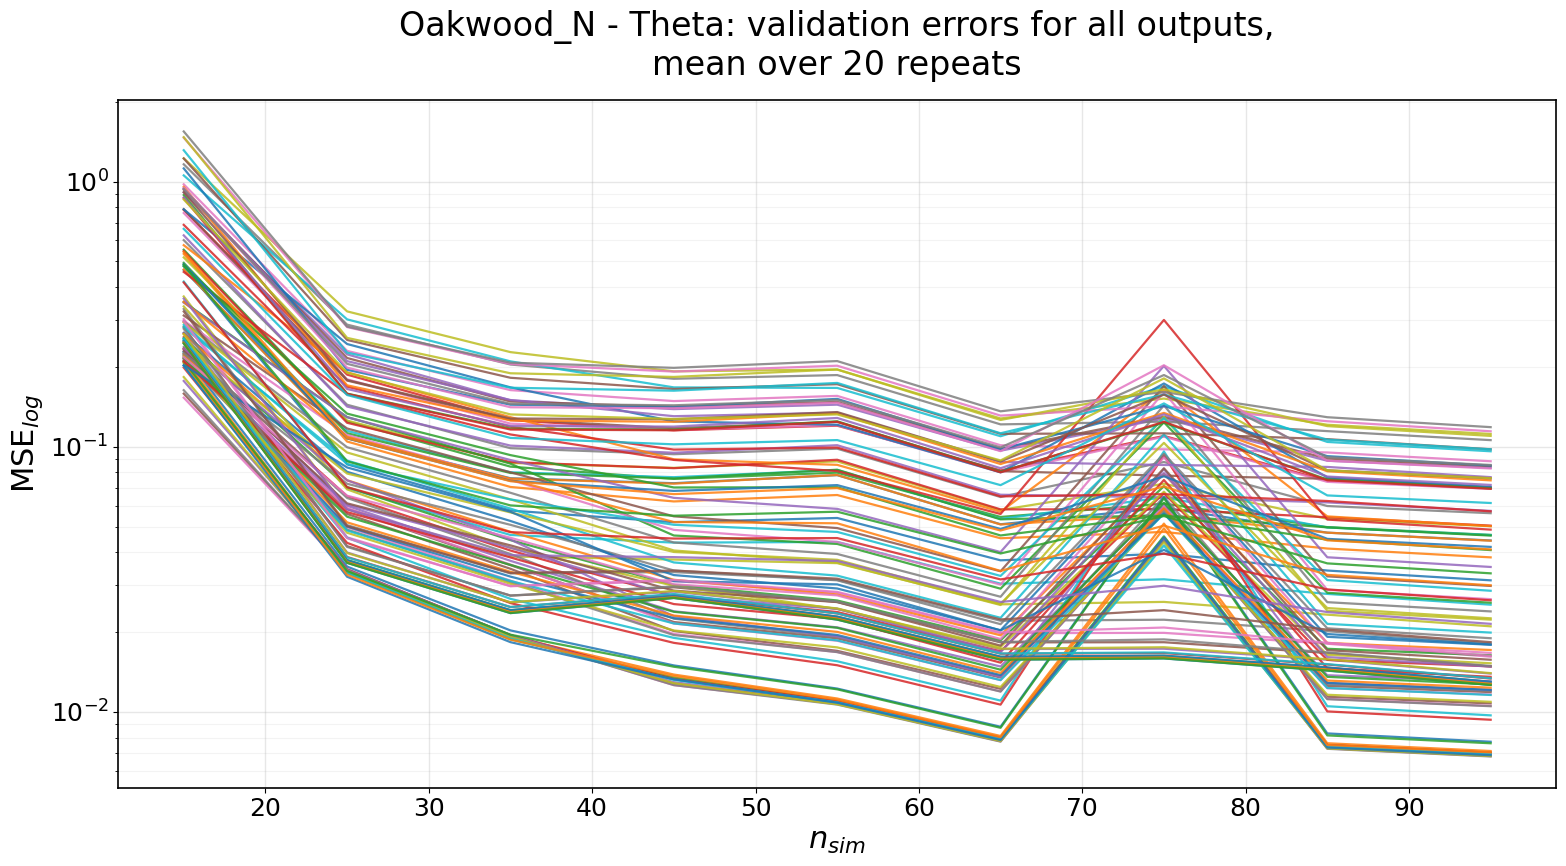

Saved: plots_output\Oakwood_N_03_Random_vs_Theta_mean_validation_error_std.png


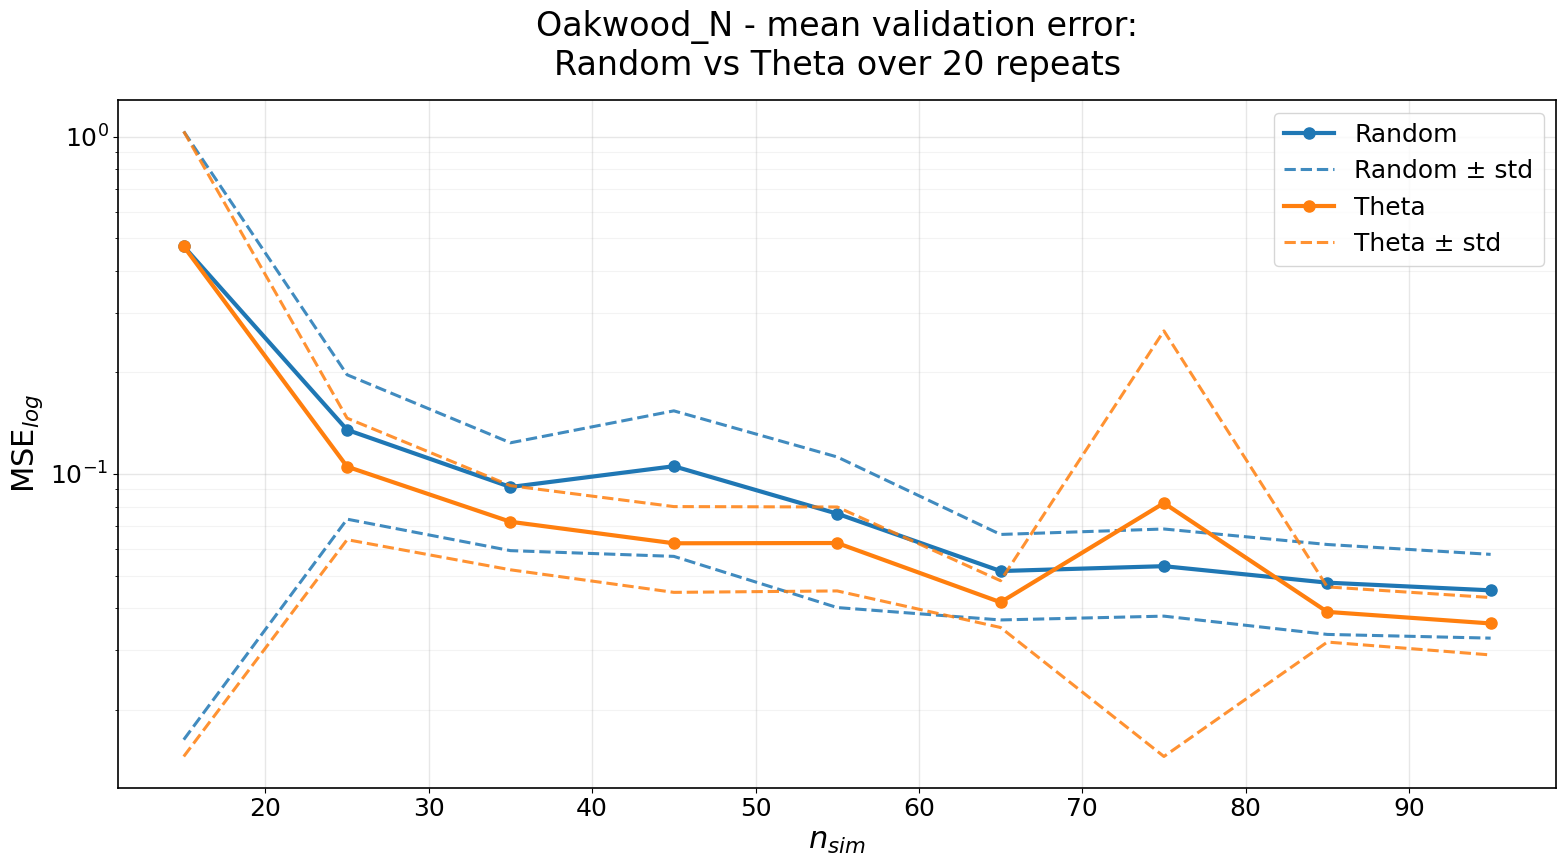

Saved: plots_output\Oakwood_N_04_Random_vs_Theta_maximum_absolute_error_std.png


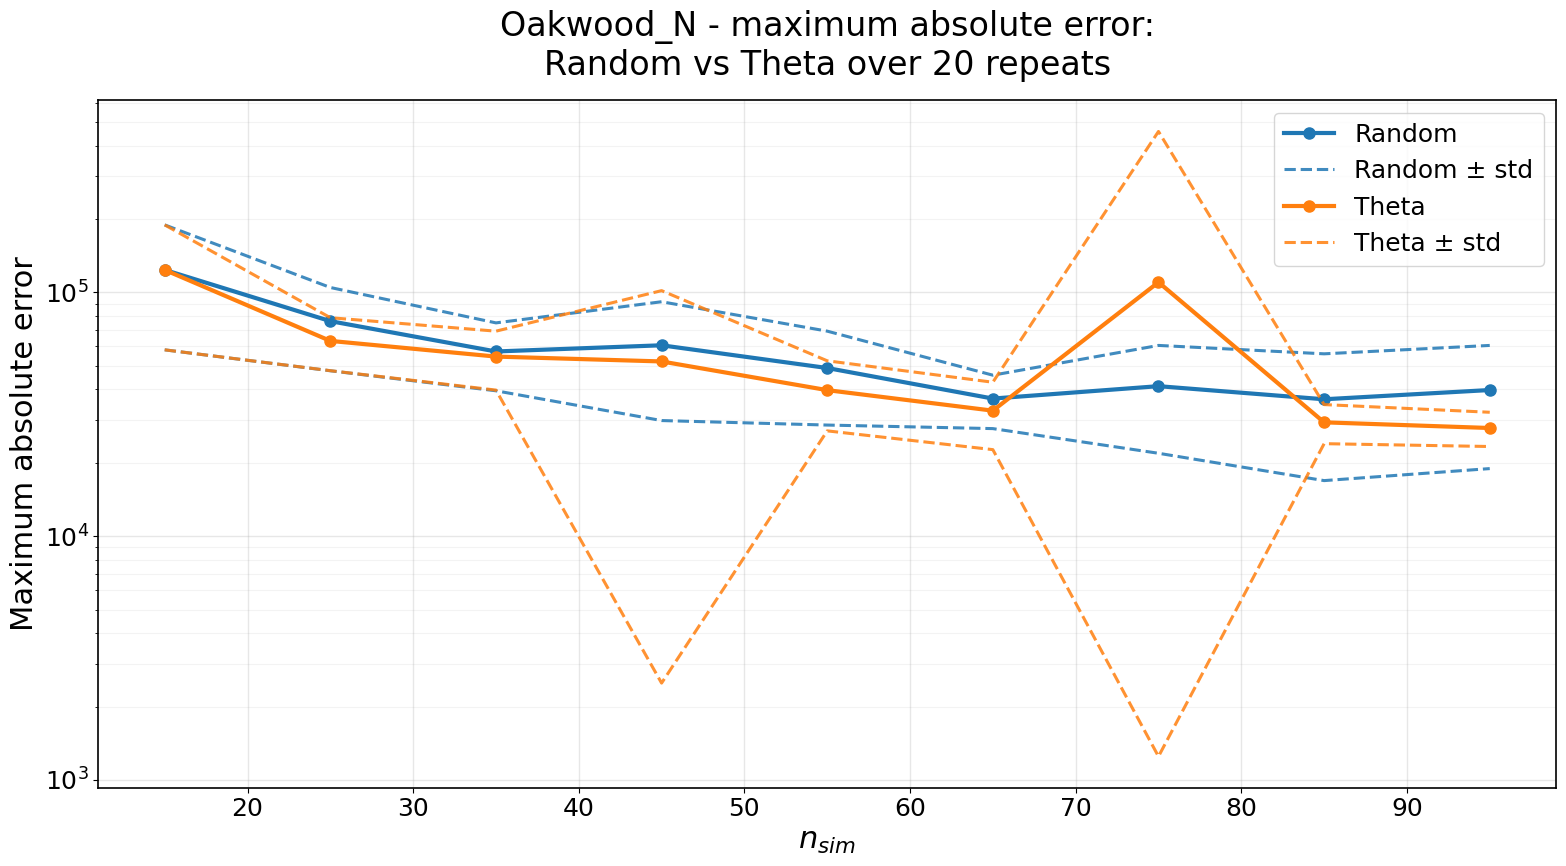

Saved: plots_output\Oakwood_V_01_Random_all_output_validation_errors.png


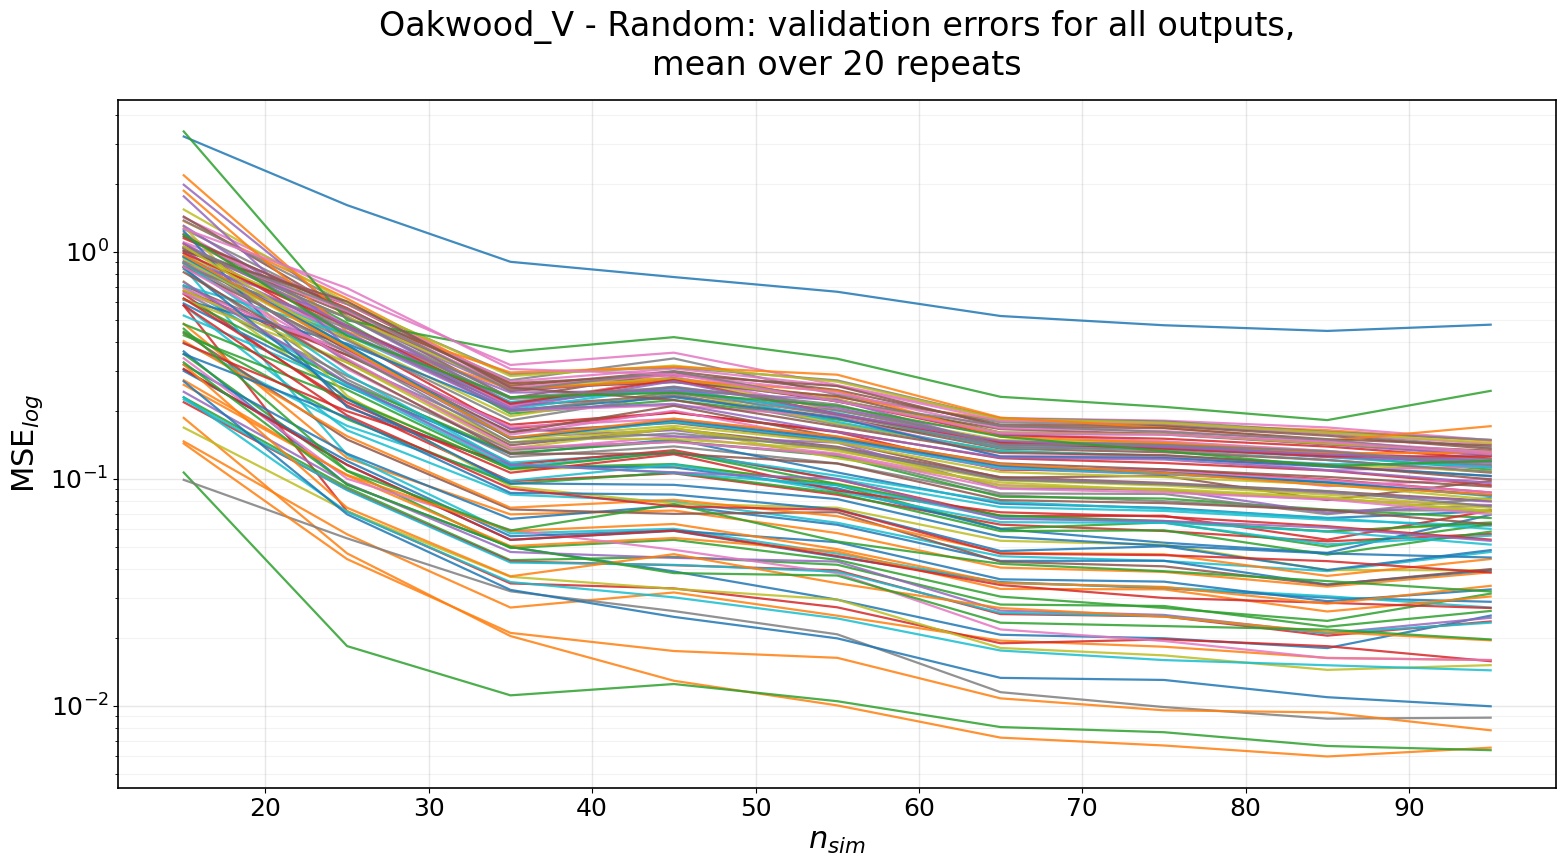

Saved: plots_output\Oakwood_V_02_Theta_all_output_validation_errors.png


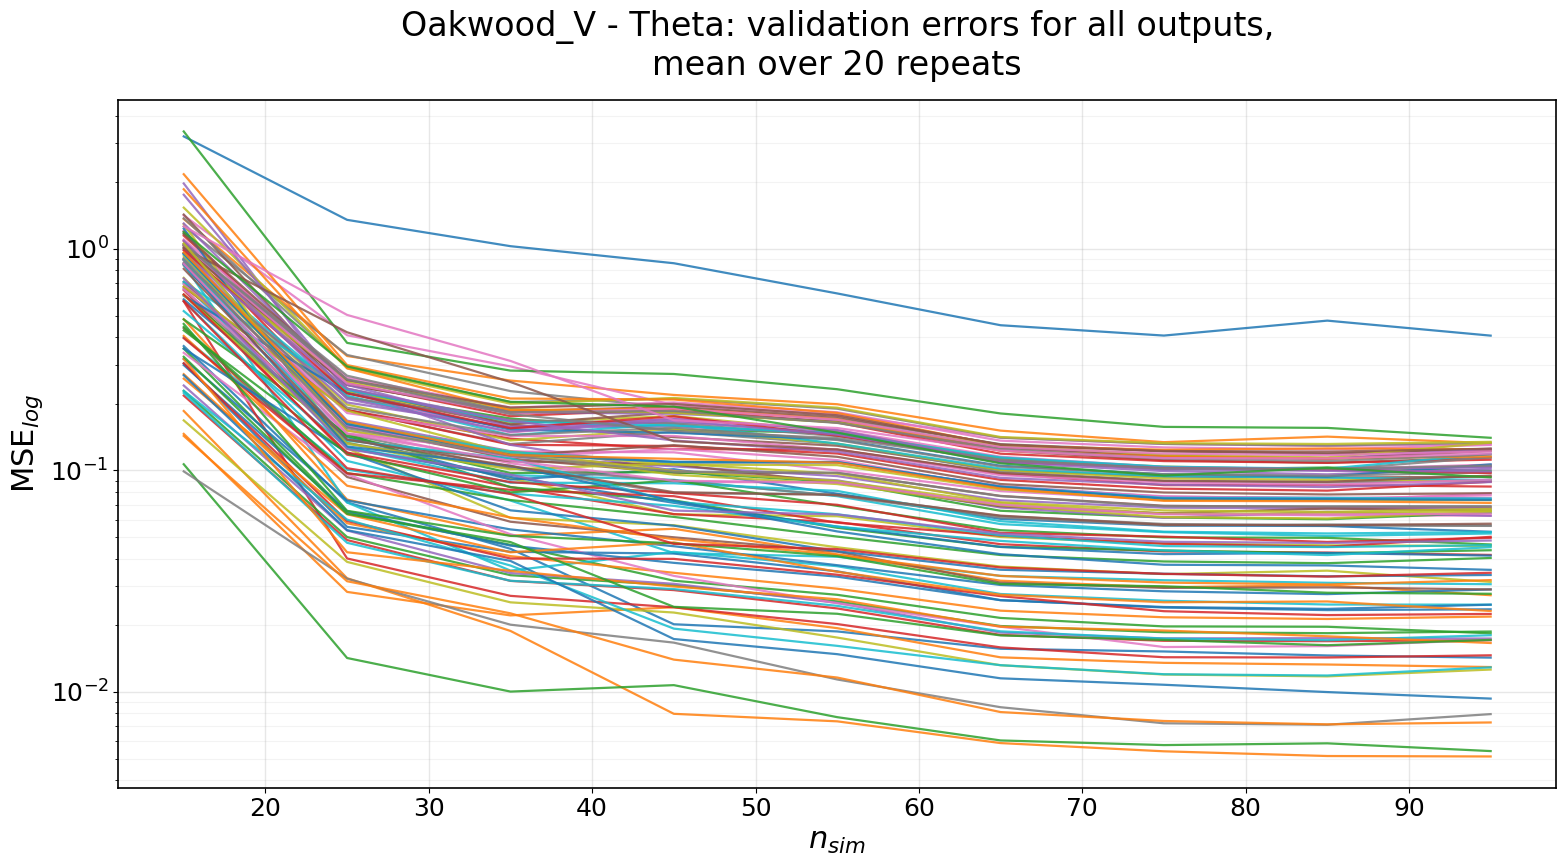

Saved: plots_output\Oakwood_V_03_Random_vs_Theta_mean_validation_error_std.png


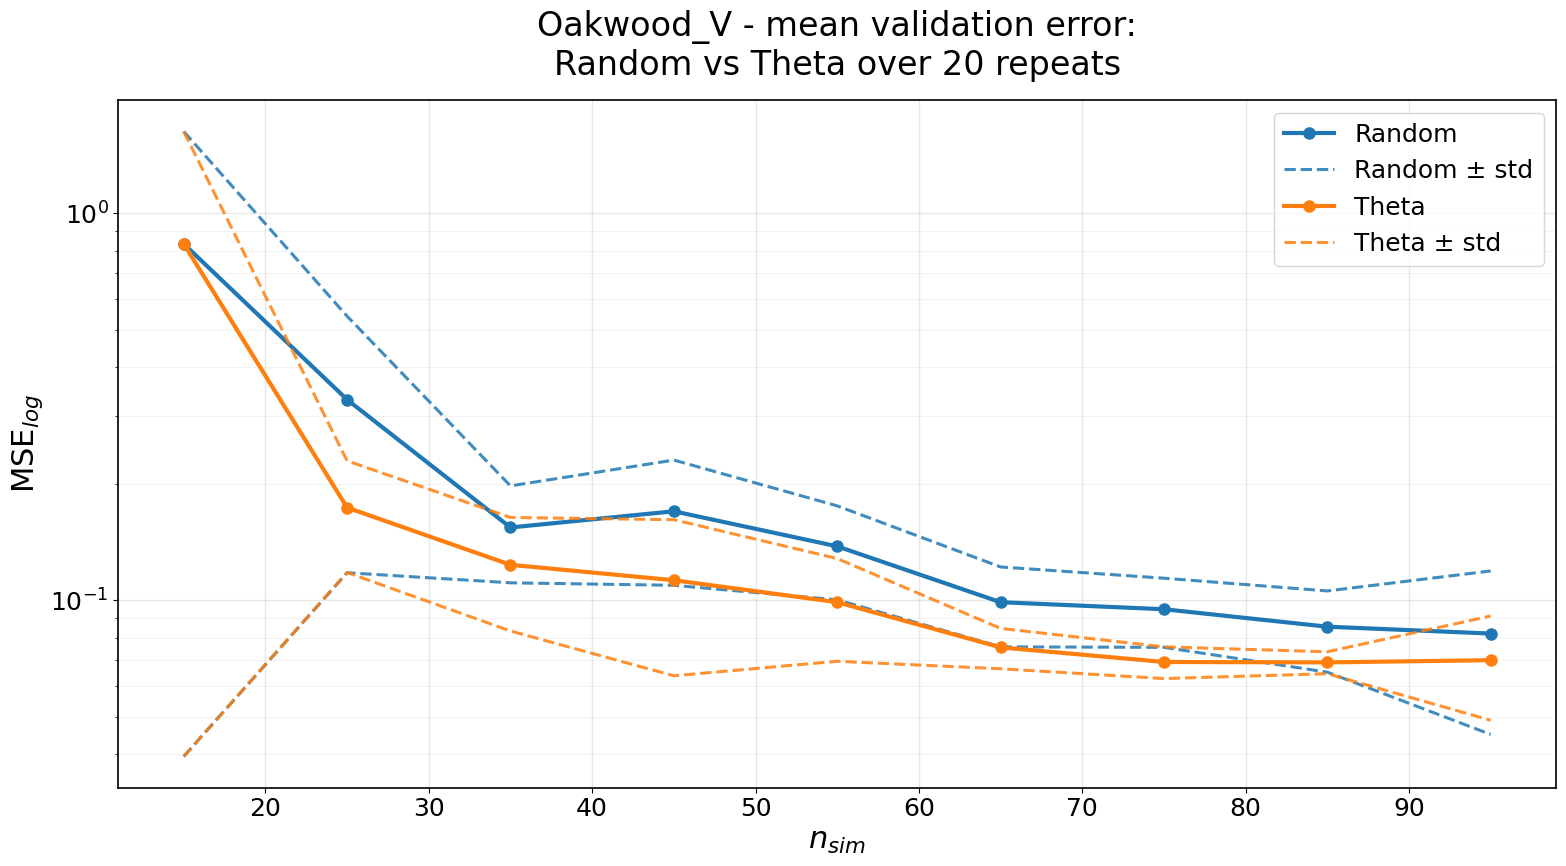

Saved: plots_output\Oakwood_V_04_Random_vs_Theta_maximum_absolute_error_std.png


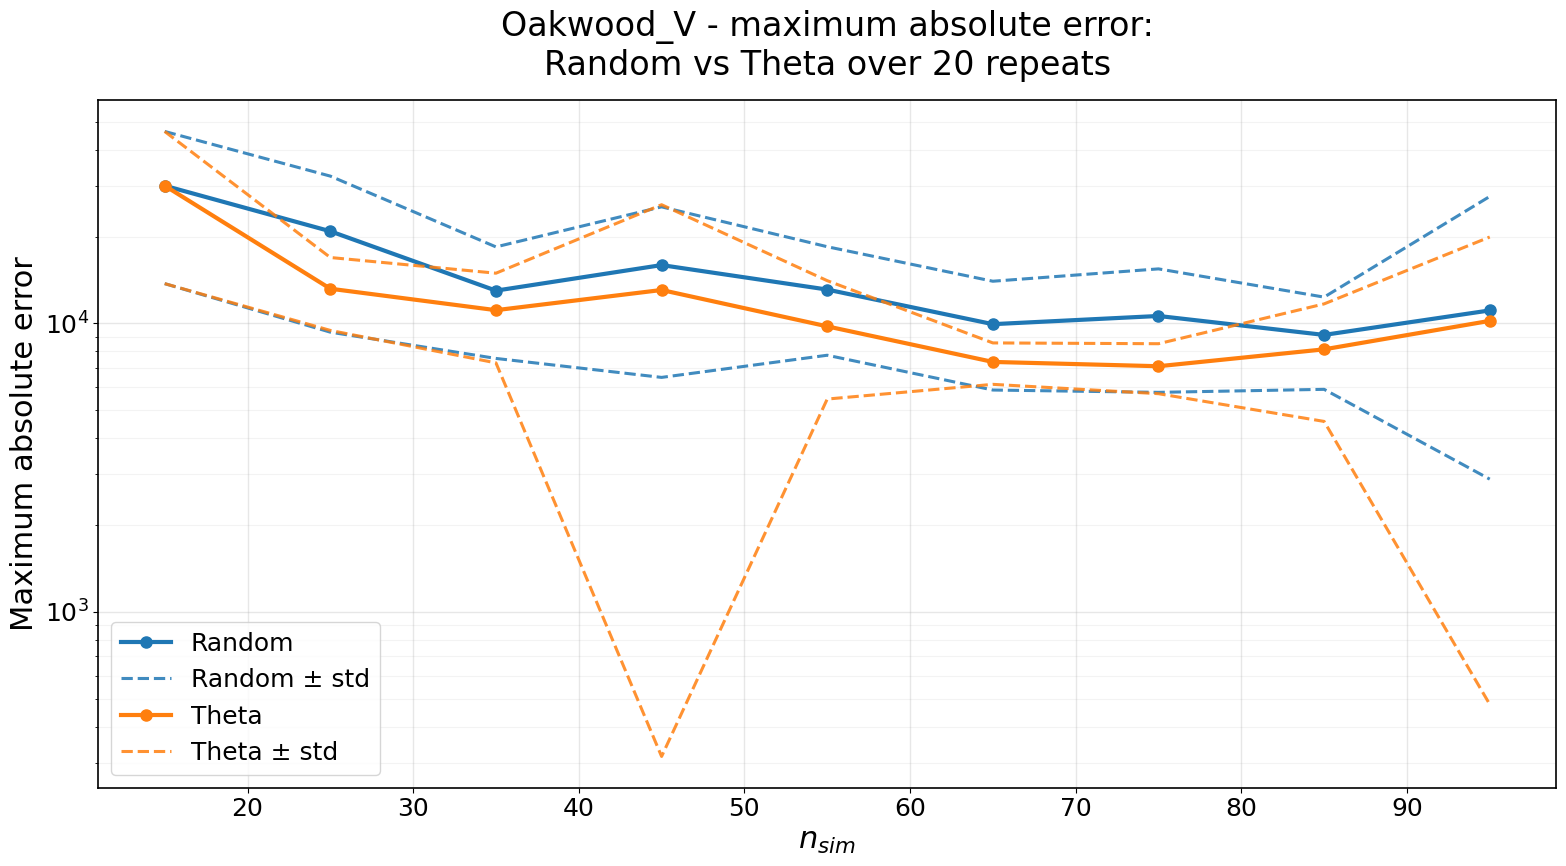

Saved: plots_output\Oakwood_M_01_Random_all_output_validation_errors.png


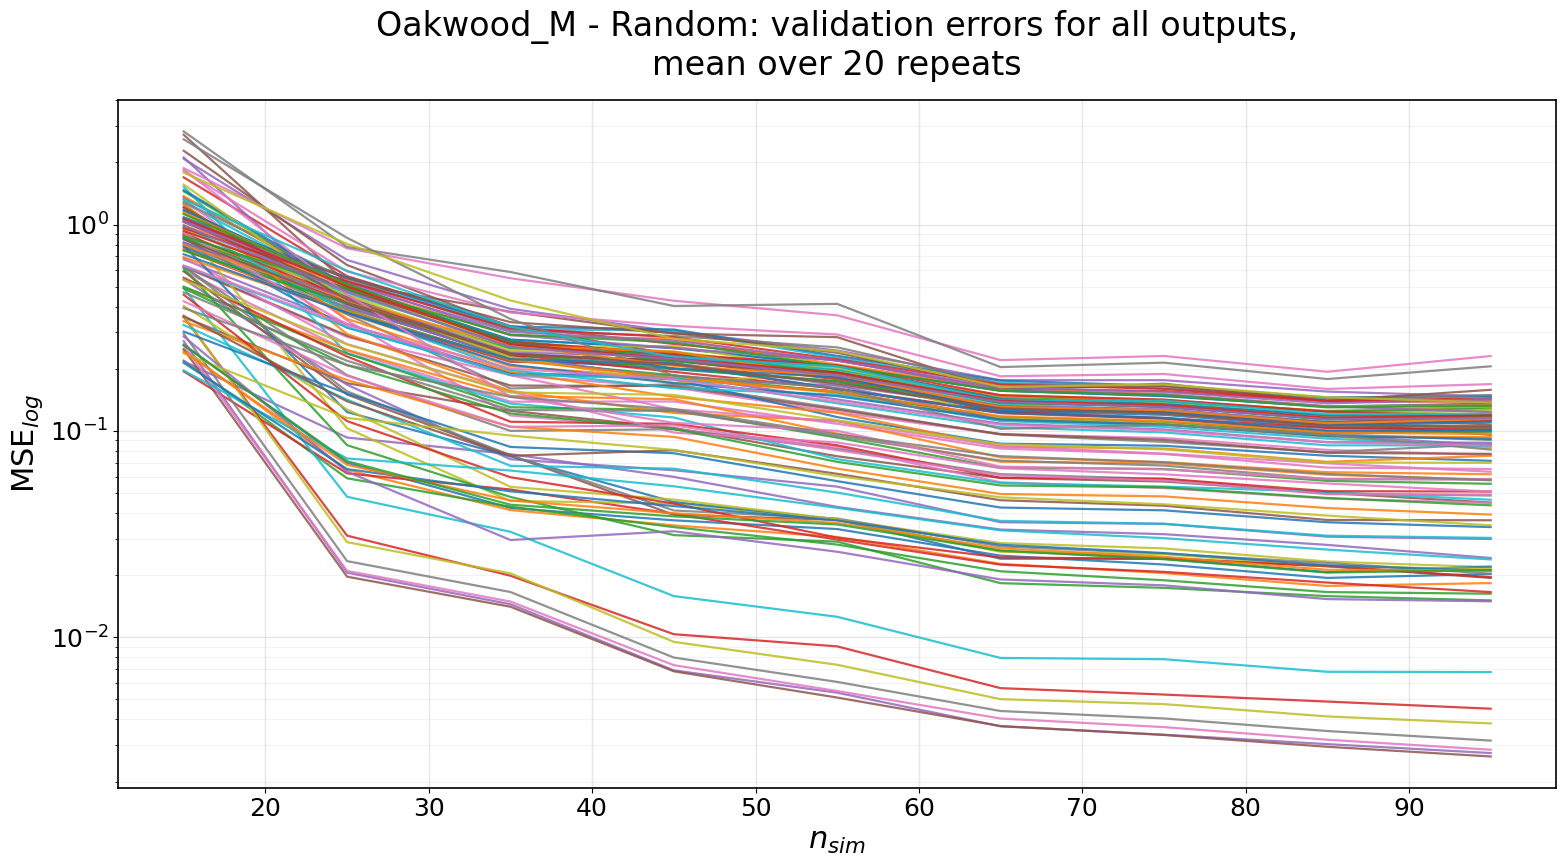

Saved: plots_output\Oakwood_M_02_Theta_all_output_validation_errors.png


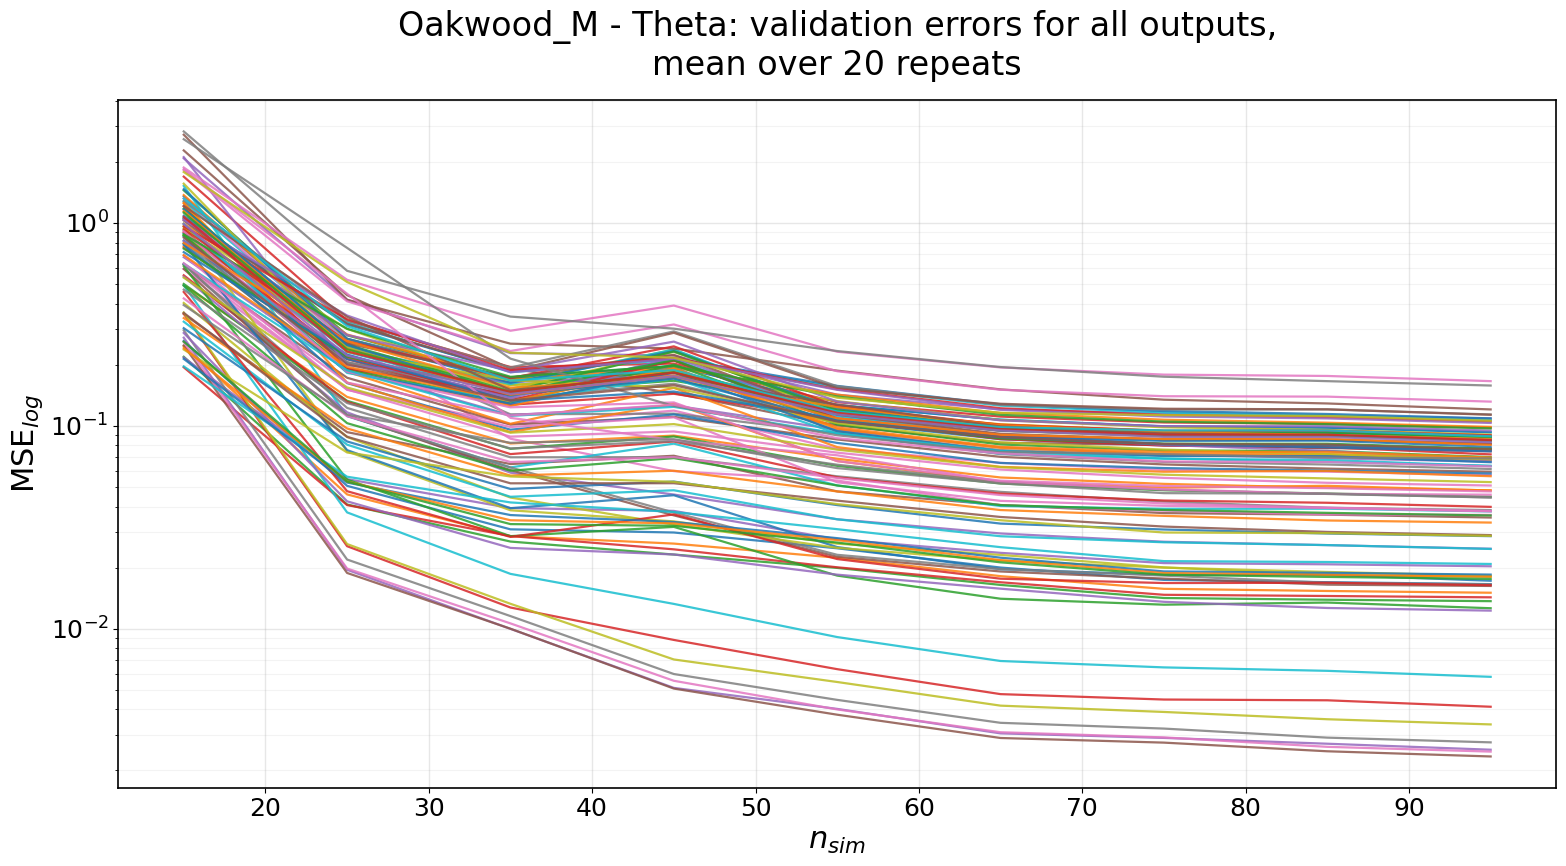

Saved: plots_output\Oakwood_M_03_Random_vs_Theta_mean_validation_error_std.png


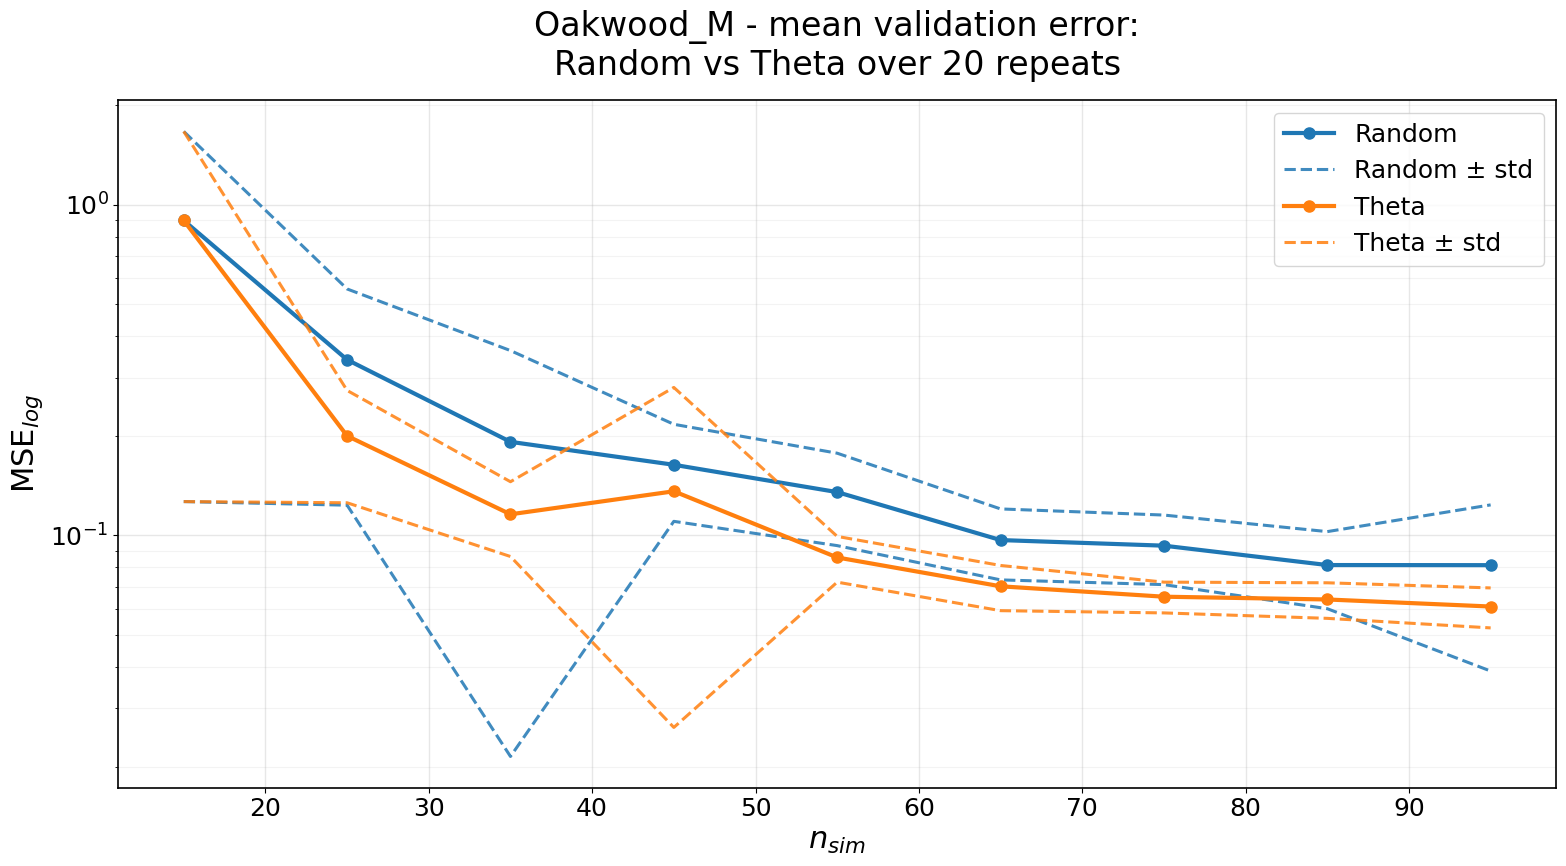

Saved: plots_output\Oakwood_M_04_Random_vs_Theta_maximum_absolute_error_std.png


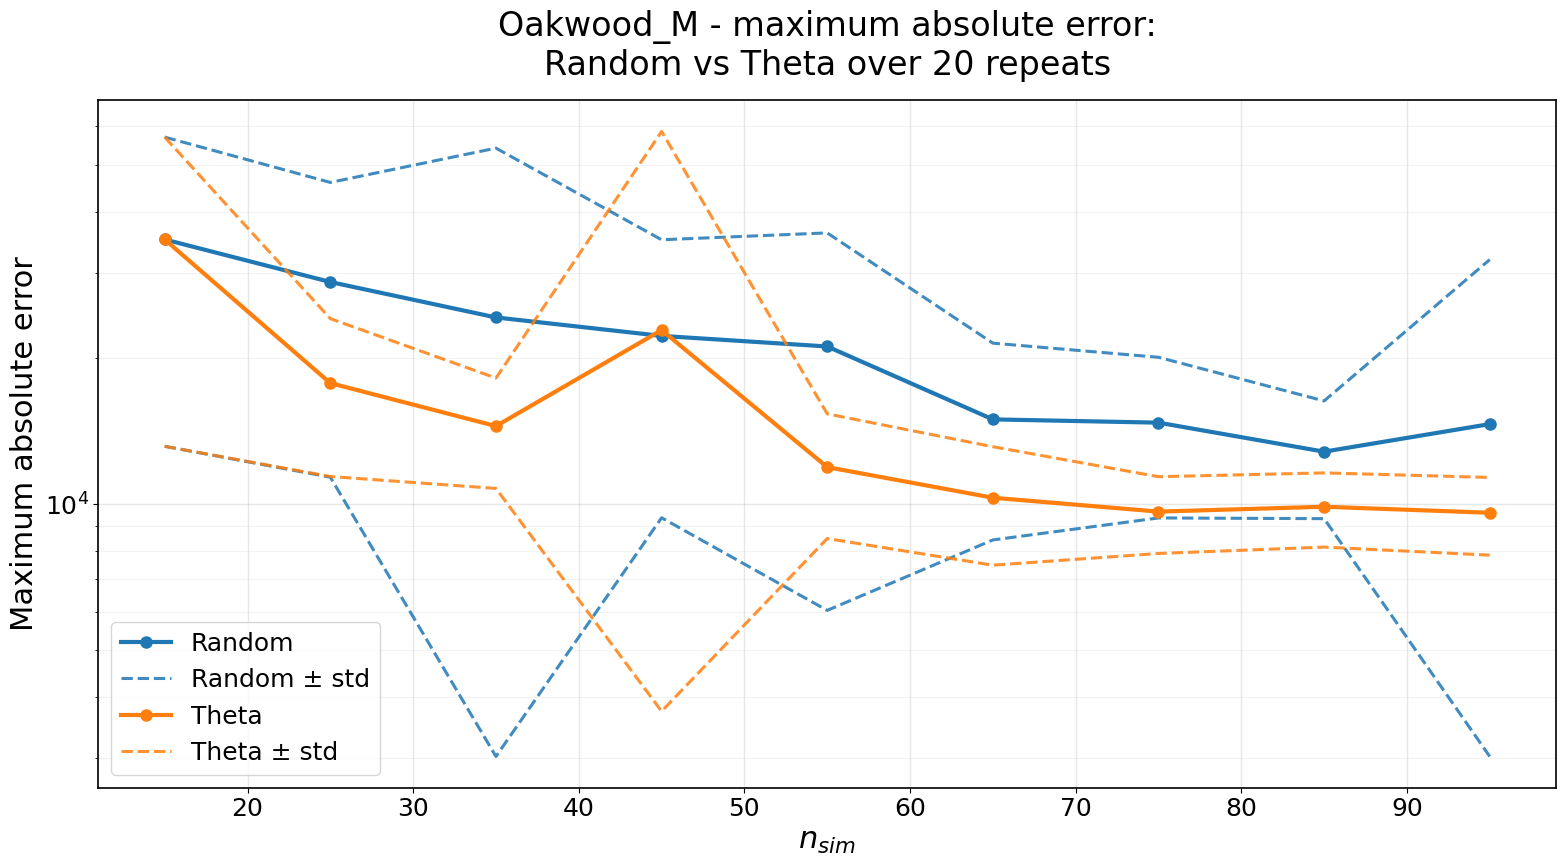

In [42]:
# ============================================================
# Grafy
# ============================================================

import os
import re

# ------------------------------------------------------------
# Složka pro ukládání obrázků
# ------------------------------------------------------------

PLOTS_DIR = "plots_output"
os.makedirs(PLOTS_DIR, exist_ok=True)

SAVE_DPI = 300


def safe_filename(text):
    """Bezpečný název souboru bez mezer a speciálních znaků."""
    text = str(text)
    text = text.replace(" ", "_")
    text = re.sub(r"[^A-Za-z0-9_\-]+", "", text)
    return text


def save_current_figure(fig, dataset_name, plot_name):
    """Uloží aktuální obrázek do složky PLOTS_DIR."""
    filename = f"{safe_filename(dataset_name)}_{safe_filename(plot_name)}.png"
    filepath = os.path.join(PLOTS_DIR, filename)

    fig.savefig(
        filepath,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved: {filepath}")


# Globální nastavení velikostí pro prezentaci
PRESENTATION_FIGSIZE = (16, 9)

TITLE_SIZE = 24
LABEL_SIZE = 22
TICK_SIZE = 18
LEGEND_SIZE = 18

MAIN_LINEWIDTH = 3.0
STD_LINEWIDTH = 2.2
ALL_OUTPUT_LINEWIDTH = 1.6
MARKER_SIZE = 8

# Metody, které se mají opravdu vykreslovat.
# LHS zde záměrně není.
PLOT_METHODS = ["Random", "Theta"]

plt.rcParams.update({
    "font.size": TICK_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})


def format_presentation_axes(ax):
    """Jednotné formátování grafu pro prezentaci."""
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.tick_params(axis="both", which="minor", labelsize=TICK_SIZE - 2)

    ax.grid(True, which="major", alpha=0.30, linewidth=1.0)
    ax.grid(True, which="minor", alpha=0.15, linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


def plot_mean_with_band(ax, x, curves, label):
    curves = np.asarray(curves, dtype=float)

    mean = np.nanmean(curves, axis=0)
    std = np.nanstd(curves, axis=0)

    lower = mean - std
    upper = mean + std

    # --------------------------------------------------------
    # Na logaritmické ose nelze vykreslit hodnoty <= 0.
    # Aby se čára směrodatné odchylky nikdy nepřerušila,
    # hodnoty <= 0 se oříznou na malou kladnou hodnotu.
    # --------------------------------------------------------

    positive_values = np.concatenate([
        mean[np.isfinite(mean) & (mean > 0)],
        lower[np.isfinite(lower) & (lower > 0)],
        upper[np.isfinite(upper) & (upper > 0)],
    ])

    if positive_values.size > 0:
        log_floor = np.nanmin(positive_values) * 0.50
    else:
        log_floor = 1e-12

    lower = np.where(np.isfinite(lower), lower, log_floor)
    upper = np.where(np.isfinite(upper), upper, log_floor)

    lower = np.maximum(lower, log_floor)
    upper = np.maximum(upper, log_floor)

    # Hlavní křivka = průměr
    line, = ax.plot(
        x,
        mean,
        marker="o",
        markersize=MARKER_SIZE,
        linewidth=MAIN_LINEWIDTH,
        label=label
    )

    # Barva dané metody
    color = line.get_color()

    # Dolní okraj = mean - směrodatná odchylka
    ax.plot(
        x,
        lower,
        linestyle="--",
        linewidth=STD_LINEWIDTH,
        color=color,
        alpha=0.85,
        label=f"{label} ± std"
    )

    # Horní okraj = mean + směrodatná odchylka
    ax.plot(
        x,
        upper,
        linestyle="--",
        linewidth=STD_LINEWIDTH,
        color=color,
        alpha=0.85,
        label="_nolegend_"
    )


for dataset_name, repeats in all_outputs.items():

    # ========================================================
    # 1) Graf všech výstupních křivek pro Random
    #    průměr přes opakování
    # ========================================================

    random_stack = np.asarray([
        rep["errs_by_method"]["Random"]
        for rep in repeats
    ])  # repeat x n_train x n_outputs

    errs_random_mean_outputs = np.nanmean(random_stack, axis=0)

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for j in range(errs_random_mean_outputs.shape[1]):
        ax.plot(
            nsim,
            errs_random_mean_outputs[:, j],
            linewidth=ALL_OUTPUT_LINEWIDTH,
            alpha=0.85
        )

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - Random: validation errors for all outputs,\n"
        f"mean over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "01_Random_all_output_validation_errors"
    )

    plt.show()


    # ========================================================
    # 2) Graf všech výstupních křivek pro Theta
    #    průměr přes opakování
    # ========================================================

    theta_stack = np.asarray([
        rep["errs_by_method"]["Theta"]
        for rep in repeats
    ])  # repeat x n_train x n_outputs

    errs_theta_mean_outputs = np.nanmean(theta_stack, axis=0)

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for j in range(errs_theta_mean_outputs.shape[1]):
        ax.plot(
            nsim,
            errs_theta_mean_outputs[:, j],
            linewidth=ALL_OUTPUT_LINEWIDTH,
            alpha=0.85
        )

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - Theta: validation errors for all outputs,\n"
        f"mean over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "02_Theta_all_output_validation_errors"
    )

    plt.show()


    # ========================================================
    # 3) Porovnání mean Random vs Theta
    #    se směrodatnou odchylkou
    # ========================================================

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for method in PLOT_METHODS:
        mean_curves = [
            np.nanmean(rep["errs_by_method"][method], axis=1)
            for rep in repeats
        ]  # repeat x n_train

        plot_mean_with_band(ax, nsim, mean_curves, method)

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - mean validation error:\n"
        f"Random vs Theta over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    ax.legend(fontsize=LEGEND_SIZE, frameon=True)
    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "03_Random_vs_Theta_mean_validation_error_std"
    )

    plt.show()


    # ========================================================
    # 4) Maximum absolute error: Random vs Theta
    #    se směrodatnou odchylkou
    # ========================================================

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for method in PLOT_METHODS:
        max_abs_curves = [
            np.nanmax(rep["max_abs_by_method"][method], axis=1)
            for rep in repeats
        ]  # repeat x n_train

        plot_mean_with_band(ax, nsim, max_abs_curves, method)

    ax.set_yscale("log")
    ax.set_ylabel("Maximum absolute error", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - maximum absolute error:\n"
        f"Random vs Theta over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    ax.legend(fontsize=LEGEND_SIZE, frameon=True)
    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "04_Random_vs_Theta_maximum_absolute_error_std"
    )

    plt.show()

In [19]:
# Kontrola výběru bodů
for dataset_name, repeats in all_outputs.items():
    print("=" * 100)
    print(f"Selection logs: {dataset_name}")
    print("=" * 100)

    logs = []

    for rep in repeats:
        for row in rep["lhs_logs"]:
            row = dict(row)
            row["method"] = "LHS"
            row["repeat"] = rep["repeat"]
            row["seed"] = rep["seed"]
            logs.append(row)

        for row in rep["theta_logs"]:
            row = dict(row)
            row["method"] = "Theta"
            row["repeat"] = rep["repeat"]
            row["seed"] = rep["seed"]
            logs.append(row)

    display(pd.DataFrame(logs))


Selection logs: Oakwood_NVM


,target_size,n_before,n_added,status,fallback,method,repeat,seed,degree,cond_limit,ratio_limit,cr,mean,max
0,15,15,0,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,25,15,10,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,35,15,20,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,45,15,30,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,55,15,40,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,55,45,10,theta_ok,False,Theta,19,20,5.0,100.0,0.70,1.000000e-08,0.007123,0.051305
356,65,55,10,theta_ok,False,Theta,19,20,2.0,10.0,0.70,1.000000e-08,0.011293,0.107195
357,75,65,10,theta_ok,False,Theta,19,20,2.0,10.0,0.50,1.000000e-08,0.011781,0.110891
358,85,75,10,theta_ok,False,Theta,19,20,5.0,100.0,0.55,1.000000e-08,0.010082,0.084539


Selection logs: Oakwood_N


,target_size,n_before,n_added,status,fallback,method,repeat,seed,degree,cond_limit,ratio_limit,cr,mean,max
0,15,15,0,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,25,15,10,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,35,15,20,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,45,15,30,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,55,15,40,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,55,45,10,theta_ok,False,Theta,19,20,5.0,100.0,0.70,1.000000e-08,0.003437,0.014076
356,65,55,10,theta_ok,False,Theta,19,20,2.0,10.0,0.70,1.000000e-08,0.006440,0.022533
357,75,65,10,theta_ok,False,Theta,19,20,2.0,10.0,0.50,1.000000e-08,0.006248,0.021569
358,85,75,10,theta_ok,False,Theta,19,20,2.0,10.0,0.40,1.000000e-08,0.008311,0.028948


Selection logs: Oakwood_V


,target_size,n_before,n_added,status,fallback,method,repeat,seed,degree,cond_limit,ratio_limit,cr,mean,max
0,15,15,0,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,25,15,10,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,35,15,20,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,45,15,30,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,55,15,40,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,55,45,10,theta_ok,False,Theta,19,20,5.0,100.0,0.70,1.000000e-08,0.005705,0.117713
356,65,55,10,theta_ok,False,Theta,19,20,5.0,100.0,0.70,1.000000e-08,0.006294,0.089369
357,75,65,10,theta_ok,False,Theta,19,20,3.0,10.0,0.55,1.000000e-08,0.013371,0.124370
358,85,75,10,theta_ok,False,Theta,19,20,3.0,10.0,0.50,1.000000e-08,0.016802,0.145301


Selection logs: Oakwood_M


,target_size,n_before,n_added,status,fallback,method,repeat,seed,degree,cond_limit,ratio_limit,cr,mean,max
0,15,15,0,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,25,15,10,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,35,15,20,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,45,15,30,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,55,15,40,lhs_ok,False,LHS,0,1,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,55,45,10,theta_ok,False,Theta,19,20,3.0,100.0,0.70,1.000000e-08,0.004921,0.025544
356,65,55,10,theta_ok,False,Theta,19,20,3.0,10.0,0.70,1.000000e-08,0.007664,0.027218
357,75,65,10,theta_ok,False,Theta,19,20,3.0,10.0,0.55,1.000000e-08,0.012650,0.039710
358,85,75,10,theta_ok,False,Theta,19,20,3.0,10.0,0.50,1.000000e-08,0.015809,0.047471
